# 01 - EDA and Preprocessing

**Phase:** 1  
**Notebook:** `01_EDA_Preprocessing.ipynb`  
**Main output:** cleaned dataset, train/validation/test split files, EDA tables, EDA figures, and reproducibility metadata.


In [ ]:
# try/except: khối kiểm tra notebook có đang chạy trên Google Colab hay không
try:
    # import google.colab: module chỉ tồn tại khi chạy trên Google Colab
    import google.colab
    # IN_COLAB = True: đánh dấu môi trường hiện tại là Colab
    IN_COLAB = True
# except: xử lý ngoại lệ — except Exception:
except Exception:
    # IN_COLAB = False: không phải Colab (local hoặc Jupyter khác)
    IN_COLAB = False

# if not IN_COLAB: chặn chạy ngoài Colab theo chính sách dự án
if not IN_COLAB:
    # raise RuntimeError: dừng notebook và báo lỗi nếu không ở Colab
    raise RuntimeError(
        # "Run this notebook in Google Colab unless local execution is explicitly approved...: thực thi lệnh Python
        "Run this notebook in Google Colab unless local execution is explicitly approved."
    # ): đóng ngoặc gọi hàm
    )


In [2]:
# from google.colab import drive: import API gắn kết Google Drive trên Colab
from google.colab import drive

# drive.mount('/content/drive'): mount Drive để đọc/ghi file dự án tại /content/drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# import json: thư viện đọc/ghi file JSON (metadata, báo cáo)
import json
# import random: thư viện sinh số ngẫu nhiên của Python
import random
# from datetime import datetime, timezone: lấy thời gian UTC để ghi metadata
from datetime import datetime, timezone
# from pathlib import Path: quản lý đường dẫn file/thư mục theo kiểu object-oriented
from pathlib import Path

# import matplotlib.pyplot as plt: vẽ biểu đồ và lưu hình EDA
import matplotlib.pyplot as plt
# import numpy as np: tính toán số học/mảng
import numpy as np
# import pandas as pd: xử lý bảng dữ liệu (DataFrame)
import pandas as pd
# import seaborn as sns: vẽ biểu đồ thống kê đẹp hơn matplotlib
import seaborn as sns
# from sklearn.model_selection import train_test_split: chia train/val/test có stratify
from sklearn.model_selection import train_test_split

# SEED = 42: hằng số seed để tái lập kết quả ngẫu nhiên
SEED = 42
# random.seed(SEED): cố định seed cho thư viện random
random.seed(SEED)
# np.random.seed(SEED): cố định seed cho numpy
np.random.seed(SEED)

# PROJECT_ROOT: thư mục gốc dự án trên Google Drive
PROJECT_ROOT = Path('/content/drive/MyDrive/Fake_reviews')
# DATASET_PATH: đường dẫn file CSV gốc đã gán nhãn fake/real
DATASET_PATH = PROJECT_ROOT / 'data' / 'final_labeled_fake_reviews.csv'
# PROCESSED_DIR: thư mục lưu dữ liệu đã làm sạch và split
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
# REPORT_TABLE_DIR: thư mục lưu bảng báo cáo EDA/cleaning
REPORT_TABLE_DIR = PROJECT_ROOT / 'reports' / 'tables'
# REPORT_FIGURE_DIR: thư mục lưu hình biểu đồ EDA
REPORT_FIGURE_DIR = PROJECT_ROOT / 'reports' / 'figures'

# TEST_SIZE = 0.15: tỷ lệ 15% dữ liệu dành cho tập test
TEST_SIZE = 0.15
# VAL_SIZE = 0.15: tỷ lệ 15% dữ liệu dành cho tập validation
VAL_SIZE = 0.15

# for path in [...]: tạo các thư mục output nếu chưa tồn tại
for path in [PROCESSED_DIR, REPORT_TABLE_DIR, REPORT_FIGURE_DIR]:
    # path.mkdir(parents=True, exist_ok=True): tạo thư mục kèm thư mục cha, không lỗi nếu đã có
    path.mkdir(parents=True, exist_ok=True)

# pd.set_option('display.max_columns', 80): hiển thị tối đa 80 cột khi in DataFrame
pd.set_option('display.max_columns', 80)
# pd.set_option('display.max_colwidth', 120): giới hạn độ rộng mỗi cột khi hiển thị
pd.set_option('display.max_colwidth', 120)
# sns.set_theme(style='whitegrid'): đặt theme seaborn có lưới nền trắng
sns.set_theme(style='whitegrid')


## Schema 

In [2]:
# TEXT_COL_OVERRIDE = None: ghi đè tên cột nội dung review; None = tự động nhận diện
TEXT_COL_OVERRIDE = None
# LABEL_COL_OVERRIDE = None: ghi đè tên cột nhãn; None = tự động nhận diện
LABEL_COL_OVERRIDE = None
# REVIEWER_COL_OVERRIDE = None: ghi đè tên cột người đánh giá; None = tự động nhận diện
REVIEWER_COL_OVERRIDE = None
# PRODUCT_COL_OVERRIDE = None: ghi đè tên cột sản phẩm; None = tự động nhận diện
PRODUCT_COL_OVERRIDE = None
# RATING_COL_OVERRIDE = None: ghi đè tên cột điểm rating; None = tự động nhận diện
RATING_COL_OVERRIDE = None
# TIMESTAMP_COL_OVERRIDE = None: ghi đè tên cột thời gian; None = tự động nhận diện
TIMESTAMP_COL_OVERRIDE = None

# LABEL_MAPPING_OVERRIDE = None: ánh xạ nhãn gốc sang 0/1; None = tự suy luận
LABEL_MAPPING_OVERRIDE = None
# Ví dụ nếu cần ghi đè thủ công:

# TEXT_CANDIDATES: danh sách tên cột ứng viên cho nội dung review
TEXT_CANDIDATES = [
    # 'review_text', 'review text', 'text', 'review', 'content', 'body',: thực thi lệnh Python
    'review_text', 'review text', 'text', 'review', 'content', 'body',
    # 'Review Text', 'Review', 'reviews.text': thực thi lệnh Python
    'Review Text', 'Review', 'reviews.text'
# ]: đóng khối danh sách
]
# LABEL_CANDIDATES: danh sách tên cột ứng viên cho nhãn fake/real
LABEL_CANDIDATES = [
    # 'label', 'class', 'target', 'fake', 'is_fake', 'is fake', 'Label',: thực thi lệnh Python
    'label', 'class', 'target', 'fake', 'is_fake', 'is fake', 'Label',
    # 'CG_OR', 'category', 'polarity': thực thi lệnh Python
    'CG_OR', 'category', 'polarity'
# ]: đóng khối danh sách
]
# REVIEWER_CANDIDATES: danh sách tên cột ứng viên cho ID người đánh giá
REVIEWER_CANDIDATES = [
    # 'reviewer_id', 'reviewer id', 'user_id', 'user id', 'userid',: thực thi lệnh Python
    'reviewer_id', 'reviewer id', 'user_id', 'user id', 'userid',
    # 'reviewerID', 'customer_id', 'author', 'username': thực thi lệnh Python
    'reviewerID', 'customer_id', 'author', 'username'
# ]: đóng khối danh sách
]
# PRODUCT_CANDIDATES: danh sách tên cột ứng viên cho ID sản phẩm
PRODUCT_CANDIDATES = [
    # 'product_id', 'product id', 'asin', 'productID', 'item_id',: thực thi lệnh Python
    'product_id', 'product id', 'asin', 'productID', 'item_id',
    # 'item id', 'product': thực thi lệnh Python
    'item id', 'product'
# ]: đóng khối danh sách
]
# RATING_CANDIDATES: danh sách tên cột ứng viên cho điểm rating/sao
RATING_CANDIDATES = [
    # 'rating', 'stars', 'score', 'overall', 'review_rating', 'rate': thực thi lệnh Python
    'rating', 'stars', 'score', 'overall', 'review_rating', 'rate'
# ]: đóng khối danh sách
]
# TIMESTAMP_CANDIDATES: danh sách tên cột ứng viên cho thời gian đăng review
TIMESTAMP_CANDIDATES = [
    # 'timestamp', 'time', 'date', 'review_time', 'review time',: thực thi lệnh Python
    'timestamp', 'time', 'date', 'review_time', 'review time',
    # 'unixReviewTime', 'reviewTime', 'created_at': thực thi lệnh Python
    'unixReviewTime', 'reviewTime', 'created_at'
# ]: đóng khối danh sách
]

# Hàm phụ trợ để chuẩn hóa một chuỗi (thường là tên cột). Nó chuyển chuỗi về chữ thường, cắt khoảng trắng ở hai đầu và thay thế dấu gạch ngang (-) hoặc dấu cách () bằng dấu gạch dưới (_).
def _normalize_name(name):
    # return: trả kết quả từ hàm
    return str(name).strip().lower().replace('-', '_').replace(' ', '_')

#Hàm tự động nhận diện ý nghĩa của các cột trong tập dữ liệu (ví dụ: đâu là cột nội dung review, đâu là cột label). Nó duyệt qua danh sách các cột hiện có và đối chiếu với danh sách các tên ứng viên (candidates). Nếu không khớp chính xác, nó sẽ dùng _normalize_name để so sánh tương đối. Cho phép người dùng ghi đè (override) nếu nhận diện sai. Nếu cột bắt buộc không được tìm thấy, nó sẽ ném ra lỗi ValueError.
def infer_column(columns, candidates, override=None, required=False, role='column'):
    # columns = ...: chuyển/chiếu thành list
    columns = list(columns)
    # if: kiểm tra điều kiện — if override:
    if override:
        # if: kiểm tra điều kiện — if override not in columns:
        if override not in columns:
            # raise ValueError(: ném lỗi và dừng cell
            raise ValueError(
                # f"{role} override '{override}' was not found. Available columns: {columns}": thực thi lệnh Python
                f"{role} override '{override}' was not found. Available columns: {columns}"
            # ): đóng ngoặc gọi hàm
            )
        # return: trả kết quả từ hàm
        return override

    # exact_lookup = ...: ép kiểu chuỗi
    exact_lookup = {str(col): col for col in columns}
    # normalized_lookup = ...: gán giá trị cho biến normalized lookup
    normalized_lookup = {_normalize_name(col): col for col in columns}

    # for: vòng lặp — for candidate in candidates:
    for candidate in candidates:
        # if: kiểm tra điều kiện — if candidate in exact_lookup:
        if candidate in exact_lookup:
            # return: trả kết quả từ hàm
            return exact_lookup[candidate]
        # normalized = ...: gán giá trị cho biến normalized
        normalized = _normalize_name(candidate)
        # if: kiểm tra điều kiện — if normalized in normalized_lookup:
        if normalized in normalized_lookup:
            # return: trả kết quả từ hàm
            return normalized_lookup[normalized]

    # for: vòng lặp — for col in columns:
    for col in columns:
        # normalized_col = ...: gán giá trị cho biến normalized col
        normalized_col = _normalize_name(col)
        # if: kiểm tra điều kiện — if any(_normalize_name(candidate) in normalized_col for candidate in c
        if any(_normalize_name(candidate) in normalized_col for candidate in candidates):
            # return: trả kết quả từ hàm
            return col

    # if: kiểm tra điều kiện — if required:
    if required:
        # raise ValueError(: ném lỗi và dừng cell
        raise ValueError(
            # f"Could not infer mandatory {role}. Set the corresponding override variable. ": thực thi lệnh Python
            f"Could not infer mandatory {role}. Set the corresponding override variable. "
            # f"Available columns: {columns}": thực thi lệnh Python
            f"Available columns: {columns}"
        # ): đóng ngoặc gọi hàm
        )
    # return: trả kết quả từ hàm
    return None


In [3]:
# if not DATASET_PATH.exists(): kiểm tra file dataset có tồn tại trên Drive không
if not DATASET_PATH.exists():
    # raise FileNotFoundError: báo lỗi nếu không tìm thấy file CSV
    raise FileNotFoundError(
        # f"Dataset not found at {DATASET_PATH}. Update PROJECT_ROOT or DATASET_PATH.": tạo tập hợp
        f"Dataset not found at {DATASET_PATH}. Update PROJECT_ROOT or DATASET_PATH."
    # ): đóng ngoặc gọi hàm
    )

# df = pd.read_csv(...): đọc toàn bộ dataset vào DataFrame pandas
df = pd.read_csv(DATASET_PATH, low_memory=False)
# original_row_count = len(df): lưu số dòng ban đầu để so sánh sau cleaning
original_row_count = len(df)

# print('Dataset loaded'): thông báo đã load xong
print('Dataset loaded')
# print('Shape:', df.shape): in kích thước (số dòng, số cột)
print('Shape:', df.shape)
# display(df.head()): hiển thị 5 dòng đầu để xem trước dữ liệu
display(df.head())
# display(df.dtypes.to_frame('dtype')): hiển thị kiểu dữ liệu từng cột
display(df.dtypes.to_frame('dtype'))


NameError: name 'DATASET_PATH' is not defined

In [ ]:
# TEXT_COL = infer_column(...): suy ra tên cột chứa nội dung review (bắt buộc)
TEXT_COL = infer_column(
    # df.columns, TEXT_CANDIDATES, TEXT_COL_OVERRIDE, required=True, role='text column...: thực thi lệnh Python
    df.columns, TEXT_CANDIDATES, TEXT_COL_OVERRIDE, required=True, role='text column'
# ): đóng ngoặc gọi hàm
)
# LABEL_COL = infer_column(...): suy ra tên cột nhãn fake/real (bắt buộc)
LABEL_COL = infer_column(
    # df.columns, LABEL_CANDIDATES, LABEL_COL_OVERRIDE, required=True, role='label col...: thực thi lệnh Python
    df.columns, LABEL_CANDIDATES, LABEL_COL_OVERRIDE, required=True, role='label column'
# ): đóng ngoặc gọi hàm
)
# REVIEWER_COL = infer_column(...): suy ra cột ID người đánh giá (tùy chọn)
REVIEWER_COL = infer_column(
    # df.columns, REVIEWER_CANDIDATES, REVIEWER_COL_OVERRIDE, required=False, role='re...: thực thi lệnh Python
    df.columns, REVIEWER_CANDIDATES, REVIEWER_COL_OVERRIDE, required=False, role='reviewer column'
# ): đóng ngoặc gọi hàm
)
# PRODUCT_COL = infer_column(...): suy ra cột ID sản phẩm (tùy chọn)
PRODUCT_COL = infer_column(
    # df.columns, PRODUCT_CANDIDATES, PRODUCT_COL_OVERRIDE, required=False, role='prod...: thực thi lệnh Python
    df.columns, PRODUCT_CANDIDATES, PRODUCT_COL_OVERRIDE, required=False, role='product column'
# ): đóng ngoặc gọi hàm
)
# RATING_COL = infer_column(...): suy ra cột điểm đánh giá sao (tùy chọn)
RATING_COL = infer_column(
    # df.columns, RATING_CANDIDATES, RATING_COL_OVERRIDE, required=False, role='rating...: thực thi lệnh Python
    df.columns, RATING_CANDIDATES, RATING_COL_OVERRIDE, required=False, role='rating column'
# ): đóng ngoặc gọi hàm
)
# TIMESTAMP_COL = infer_column(...): suy ra cột thời gian đăng review (tùy chọn)
TIMESTAMP_COL = infer_column(
    # df.columns, TIMESTAMP_CANDIDATES, TIMESTAMP_COL_OVERRIDE, required=False, role='...: thực thi lệnh Python
    df.columns, TIMESTAMP_CANDIDATES, TIMESTAMP_COL_OVERRIDE, required=False, role='timestamp column'
# ): đóng ngoặc gọi hàm
)

# schema: dictionary lưu kết quả nhận diện cột để tái sử dụng ở các phase sau
schema = {
    # 'text_col': TEXT_COL,: thực thi lệnh Python
    'text_col': TEXT_COL,
    # 'label_col': LABEL_COL,: thực thi lệnh Python
    'label_col': LABEL_COL,
    # 'reviewer_col': REVIEWER_COL,: thực thi lệnh Python
    'reviewer_col': REVIEWER_COL,
    # 'product_col': PRODUCT_COL,: thực thi lệnh Python
    'product_col': PRODUCT_COL,
    # 'rating_col': RATING_COL,: thực thi lệnh Python
    'rating_col': RATING_COL,
    # 'timestamp_col': TIMESTAMP_COL,: thực thi lệnh Python
    'timestamp_col': TIMESTAMP_COL,
# }: đóng khối từ điển
}

# print('Inferred schema'): thông báo đã suy luận xong schema
print('Inferred schema')
# print(json.dumps(...)): in schema dạng JSON dễ đọc
print(json.dumps(schema, indent=2, ensure_ascii=False))


Inferred schema
{
  "text_col": "text",
  "label_col": "label",
  "reviewer_col": "user_id",
  "product_col": "asin",
  "rating_col": "rating",
  "timestamp_col": "timestamp"
}


##EDA

Phần này bao gồm phân bố nhãn, các giá trị bị thiếu, các dòng trùng lặp, độ dài đánh giá, mức mất cân bằng lớp, và các phần tóm tắt tùy chọn theo người đánh giá/sản phẩm/điểm số/thời gian.

In [ ]:
# missing_counts: đếm số giá trị thiếu (NaN) theo từng cột, sắp xếp giảm dần
missing_counts = df.isna().sum().sort_values(ascending=False)
# duplicate_row_count: tổng số dòng trùng hoàn toàn
duplicate_row_count = int(df.duplicated().sum())
# duplicate_text_label_count: số dòng trùng cả nội dung review và nhãn
duplicate_text_label_count = int(df.duplicated(subset=[TEXT_COL, LABEL_COL]).sum())

# label_counts: đếm số lượng từng giá trị nhãn (kể cả NaN)
label_counts = df[LABEL_COL].value_counts(dropna=False)
# label_percent: tỷ lệ phần trăm từng nhãn
label_percent = df[LABEL_COL].value_counts(dropna=False, normalize=True).mul(100).round(2)
# label_distribution: bảng phân phối nhãn gồm count và percent
label_distribution = pd.DataFrame({
    # 'count': label_counts,: thực thi lệnh Python
    'count': label_counts,
    # 'percent': label_percent,: thực thi lệnh Python
    'percent': label_percent,
# }): đóng từ điển hoặc DataFrame constructor
})

# review_length: độ dài review tính theo số ký tự
review_length = df[TEXT_COL].fillna('').astype(str).str.len()
# review_word_count: độ dài review tính theo số từ
review_word_count = df[TEXT_COL].fillna('').astype(str).str.split().str.len()
# review_length_summary: thống kê mô tả độ dài ký tự và số từ
review_length_summary = pd.DataFrame({
    # 'char_length': review_length.describe(),: thống kê mô tả
    'char_length': review_length.describe(),
    # 'word_count': review_word_count.describe(),: thống kê mô tả
    'word_count': review_word_count.describe(),
# }): đóng từ điển hoặc DataFrame constructor
})

# non_null_label_counts: đếm nhãn sau khi bỏ giá trị thiếu
non_null_label_counts = df[LABEL_COL].dropna().value_counts()
# class_imbalance_ratio: tỷ lệ mất cân bằng lớp (max/min), None nếu không tính được
class_imbalance_ratio = None
# if: chỉ tính imbalance khi có ít nhất 2 lớp và lớp nhỏ nhất > 0
if len(non_null_label_counts) >= 2 and non_null_label_counts.min() > 0:
    # class_imbalance_ratio = ...: ép kiểu số thực
    class_imbalance_ratio = float(non_null_label_counts.max() / non_null_label_counts.min())

# print/display: in kết quả EDA cơ bản ra màn hình
print('Missing values')
# display(missing_counts.to_frame('missing_count')): hiển thị bảng/kết quả trên notebook
display(missing_counts.to_frame('missing_count'))
# print('Duplicate rows:', duplicate_row_count): in thông tin ra console
print('Duplicate rows:', duplicate_row_count)
# print('Duplicate text/label rows:', duplicate_text_label_count): in thông tin ra console
print('Duplicate text/label rows:', duplicate_text_label_count)
# print('Label distribution'): in thông tin ra console
print('Label distribution')
# display(label_distribution): hiển thị bảng/kết quả trên notebook
display(label_distribution)
# print('Review length summary'): in thông tin ra console
print('Review length summary')
# display(review_length_summary): hiển thị bảng/kết quả trên notebook
display(review_length_summary)
# print('Class imbalance ratio:', class_imbalance_ratio): in thông tin ra console
print('Class imbalance ratio:', class_imbalance_ratio)


Missing values


,missing_count
text,12
title,10
rating,0
images,0
asin,0
parent_asin,0
user_id,0
timestamp,0
helpful_vote,0
verified_purchase,0


Duplicate rows: 0
Duplicate text/label rows: 7247
Label distribution


,count,percent
label,,
0,25281,50.56
1,24719,49.44


Review length summary


,char_length,word_count
count,50000.000000,50000.000000
mean,157.984720,29.829920
std,243.282964,45.402659
min,0.000000,0.000000
25%,29.000000,5.000000
50%,84.000000,16.000000
75%,193.000000,37.000000
max,7550.000000,1221.000000


Class imbalance ratio: 1.0227355475545128


In [ ]:
# optional_summaries: dictionary lưu thống kê tùy chọn theo cột có sẵn
optional_summaries = {}

# if RATING_COL: phân tích rating nếu dataset có cột điểm sao
if RATING_COL:
    # optional_summaries['rating_summary'] = df[RATING_COL].describe(include='all').to...: thống kê mô tả
    optional_summaries['rating_summary'] = df[RATING_COL].describe(include='all').to_dict()
    # print('Rating summary'): in thông tin ra console
    print('Rating summary')
    # display(df[RATING_COL].describe(include='all')): thống kê mô tả
    display(df[RATING_COL].describe(include='all'))

# if REVIEWER_COL: phân tích người đánh giá nếu có cột reviewer
if REVIEWER_COL:
    # reviewer_counts = ...: đếm tần suất từng giá trị
    reviewer_counts = df[REVIEWER_COL].value_counts(dropna=False)
    # optional_summaries['reviewer_count'] = int(reviewer_counts.shape[0]): ép kiểu số nguyên
    optional_summaries['reviewer_count'] = int(reviewer_counts.shape[0])
    # optional_summaries['top_reviewers'] = reviewer_counts.head(10).to_dict(): xem vài dòng đầu
    optional_summaries['top_reviewers'] = reviewer_counts.head(10).to_dict()
    # print('Reviewer count:', optional_summaries['reviewer_count']): in thông tin ra console
    print('Reviewer count:', optional_summaries['reviewer_count'])
    # display(reviewer_counts.head(10).to_frame('reviews')): hiển thị bảng/kết quả trên notebook
    display(reviewer_counts.head(10).to_frame('reviews'))

# if PRODUCT_COL: phân tích sản phẩm nếu có cột product
if PRODUCT_COL:
    # product_counts = ...: đếm tần suất từng giá trị
    product_counts = df[PRODUCT_COL].value_counts(dropna=False)
    # optional_summaries['product_count'] = int(product_counts.shape[0]): ép kiểu số nguyên
    optional_summaries['product_count'] = int(product_counts.shape[0])
    # optional_summaries['top_products'] = product_counts.head(10).to_dict(): xem vài dòng đầu
    optional_summaries['top_products'] = product_counts.head(10).to_dict()
    # print('Product count:', optional_summaries['product_count']): in thông tin ra console
    print('Product count:', optional_summaries['product_count'])
    # display(product_counts.head(10).to_frame('reviews')): hiển thị bảng/kết quả trên notebook
    display(product_counts.head(10).to_frame('reviews'))

# if TIMESTAMP_COL: kiểm tra khả năng parse cột thời gian
if TIMESTAMP_COL:
    # timestamp_preview = ...: gán giá trị cho biến timestamp preview
    timestamp_preview = pd.to_datetime(df[TIMESTAMP_COL], errors='coerce')
    # optional_summaries['timestamp_parse_rate'] = float(timestamp_preview.notna().mea...: ép kiểu số thực
    optional_summaries['timestamp_parse_rate'] = float(timestamp_preview.notna().mean())
    # optional_summaries['timestamp_min'] = str(timestamp_preview.min()): ép kiểu chuỗi
    optional_summaries['timestamp_min'] = str(timestamp_preview.min())
    # optional_summaries['timestamp_max'] = str(timestamp_preview.max()): ép kiểu chuỗi
    optional_summaries['timestamp_max'] = str(timestamp_preview.max())
    # print('Timestamp parse rate:', optional_summaries['timestamp_parse_rate']): in thông tin ra console
    print('Timestamp parse rate:', optional_summaries['timestamp_parse_rate'])
    # print('Timestamp min/max:', optional_summaries['timestamp_min'], optional_summar...: in thông tin ra console
    print('Timestamp min/max:', optional_summaries['timestamp_min'], optional_summaries['timestamp_max'])


Rating summary


,rating
count,50000.000000
mean,3.872580
std,1.580239
min,1.000000
25%,3.000000
50%,5.000000
75%,5.000000
max,5.000000


Reviewer count: 49370


,reviews
user_id,
AFDYIK3FNPY2JFBQYUWC6GSBMIRQ_2,10
AEOK4TQIKGO23SJKZ6PW4FETNNDA_1,10
AG73BVBKUOH22USSFJA5ZWL7AKXA,9
AEZP6Z2C5AVQDZAJECQYZWQRNG3Q,7
AFDYIK3FNPY2JFBQYUWC6GSBMIRQ_1,7
AHY2TURQPNIDXZGH2CMQLZ343YMQ,7
AFXF3EGQTQDXMRLDWFU7UBFQZB7Q,7
AGZUJTI7A3JFKB4FP5JOH6NVAJIQ_1,6
AGFAOH3NMW2D7YV3QVZSTXMTSKIQ,6


Product count: 29159


,reviews
asin,
B00EEN2HCS,126
B007IAE5WY,100
B07C533XCW,98
B00R1TAN7I,95
B08L5KN7X4,83
B019GBG0IE,80
B0092MCQZ4,73
B0719KWG8H,72
B0107QYW14,63


Timestamp parse rate: 1.0
Timestamp min/max: 2003-09-17 23:06:00 2025-06-15 15:06:00


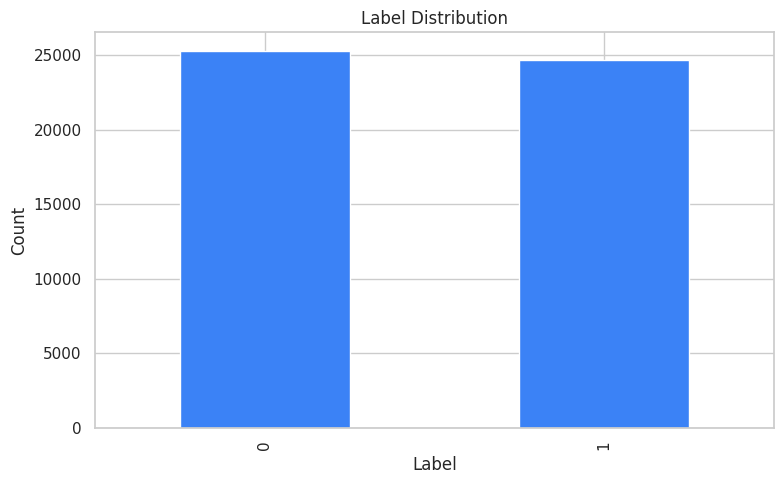

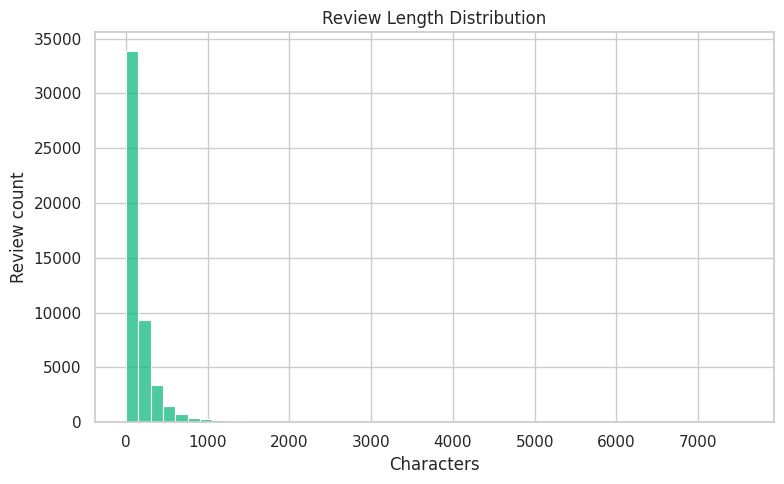

Saved figures:
/content/drive/MyDrive/Fake_reviews/reports/figures/phase1_label_distribution.png
/content/drive/MyDrive/Fake_reviews/reports/figures/phase1_review_length_distribution.png


In [ ]:
# label_plot_path: đường dẫn lưu biểu đồ phân phối nhãn
label_plot_path = REPORT_FIGURE_DIR / 'phase1_label_distribution.png'
# length_plot_path: đường dẫn lưu biểu đồ phân phối độ dài review
length_plot_path = REPORT_FIGURE_DIR / 'phase1_review_length_distribution.png'

# plt.figure: tạo figure biểu đồ cột phân phối nhãn
plt.figure(figsize=(8, 5))
# label_counts.plot(kind='bar'): vẽ bar chart số lượng từng nhãn
label_counts.plot(kind='bar', color='#3B82F6')
# plt.title('Label Distribution'): đặt tiêu đề biểu đồ
plt.title('Label Distribution')
# plt.xlabel('Label'): đặt nhãn trục X
plt.xlabel('Label')
# plt.ylabel('Count'): đặt nhãn trục Y
plt.ylabel('Count')
# plt.tight_layout(): tự chỉnh lề biểu đồ
plt.tight_layout()
# plt.savefig: lưu hình phân phối nhãn ra file PNG
plt.savefig(label_plot_path, dpi=160)
# plt.show(): hiển thị biểu đồ
plt.show()

# plt.figure: tạo figure histogram độ dài review
plt.figure(figsize=(8, 5))
# sns.histplot: vẽ histogram phân phối độ dài ký tự review
sns.histplot(review_length, bins=50, color='#10B981')
# plt.title('Review Length Distribution'): đặt tiêu đề biểu đồ
plt.title('Review Length Distribution')
# plt.xlabel('Characters'): đặt nhãn trục X
plt.xlabel('Characters')
# plt.ylabel('Review count'): đặt nhãn trục Y
plt.ylabel('Review count')
# plt.tight_layout(): tự chỉnh lề biểu đồ
plt.tight_layout()
# plt.savefig: lưu hình histogram độ dài review
plt.savefig(length_plot_path, dpi=160)
# plt.show(): hiển thị biểu đồ
plt.show()

# print('Saved figures:'): in thông tin ra console
print('Saved figures:')
# print(label_plot_path): in thông tin ra console
print(label_plot_path)
# print(length_plot_path): in thông tin ra console
print(length_plot_path)


## Cleaning Policy

Default rules:

- Loại bỏ khoảng trắng thừa trong văn bản đánh giá.
- Chuyển các chuỗi rỗng thành giá trị thiếu.
- Xóa các dòng thiếu phần văn bản hoặc nhãn bắt buộc.
- Chuẩn hóa nhãn về dạng nhị phân khi việc ánh xạ là rõ ràng.
- Xóa các cặp văn bản/nhãn bị trùng khi DROP_DUPLICATES = True.

If labels cannot be mapped safely, set `LABEL_MAPPING_OVERRIDE` explicitly.

In [10]:
# DROP_DUPLICATES = True: có xóa dòng trùng text+label hay không
DROP_DUPLICATES = True
# DUPLICATE_SUBSET: các cột dùng để xác định dòng trùng lặp
DUPLICATE_SUBSET = [TEXT_COL, LABEL_COL]

# TRUE_LABELS: tập giá trị nhãn được coi là fake (ánh xạ sang 1)
TRUE_LABELS = {'1', 'true', 'fake', 'f', 'cg', 'computer-generated', 'computer_generated', 'deceptive', 'spam'}
# FALSE_LABELS: tập giá trị nhãn được coi là real (ánh xạ sang 0)
FALSE_LABELS = {'0', 'false', 'real', 'r', 'or', 'original', 'truthful', 'genuine', 'non-fake', 'non_fake'}


# normalize_label_series: chuẩn hóa cột nhãn về 0/1 (real/fake)
def normalize_label_series(series, mapping_override=None):
    # raw = ...: gán giá trị cho biến raw
    raw = series.copy()
    # non_missing = ...: xóa dòng/cột có giá trị thiếu
    non_missing = raw.dropna()

    # if: kiểm tra điều kiện — if mapping_override is not None:
    if mapping_override is not None:
        # mapped = ...: gán giá trị cho biến mapped
        mapped = raw.map(mapping_override)
        # unmapped = ...: sắp xếp danh sách
        unmapped = sorted(set(non_missing.unique()) - set(mapping_override.keys()))
        # if: kiểm tra điều kiện — if unmapped:
        if unmapped:
            # raise ValueError(f'LABEL_MAPPING_OVERRIDE is missing values: {unmapped}'): ném lỗi và dừng cell
            raise ValueError(f'LABEL_MAPPING_OVERRIDE is missing values: {unmapped}')
        # return: ép kiểu dữ liệu cột
        return mapped.astype('int8')

    # if: kiểm tra điều kiện — if pd.api.types.is_numeric_dtype(non_missing):
    if pd.api.types.is_numeric_dtype(non_missing):
        # unique_values = ...: sắp xếp danh sách
        unique_values = sorted(non_missing.unique().tolist())
        # if: kiểm tra điều kiện — if set(unique_values).issubset({0, 1}):
        if set(unique_values).issubset({0, 1}):
            # return: ép kiểu dữ liệu cột
            return raw.astype('Int64').astype('int8')
        # if: kiểm tra điều kiện — if len(unique_values) == 2:
        if len(unique_values) == 2:
            # mapping = ...: gán giá trị cho biến mapping
            mapping = {unique_values[0]: 0, unique_values[1]: 1}
            # print('Numeric binary labels mapped as:', mapping): in thông tin ra console
            print('Numeric binary labels mapped as:', mapping)
            # return: ép kiểu dữ liệu cột
            return raw.map(mapping).astype('int8')

    # normalized = ...: ép kiểu dữ liệu cột
    normalized = raw.astype(str).str.strip().str.lower()
    # unique_normalized = ...: sắp xếp danh sách
    unique_normalized = sorted(set(normalized[raw.notna()].unique()))
    # if: kiểm tra điều kiện — if set(unique_normalized).issubset(TRUE_LABELS | FALSE_LABELS):
    if set(unique_normalized).issubset(TRUE_LABELS | FALSE_LABELS):
        # mapping = ...: gán giá trị cho biến mapping
        mapping = {value: 1 for value in TRUE_LABELS}
        # mapping.update({value: 0 for value in FALSE_LABELS}): thực thi lệnh Python
        mapping.update({value: 0 for value in FALSE_LABELS})
        # return: ép kiểu dữ liệu cột
        return normalized.map(mapping).astype('int8')

    # if: kiểm tra điều kiện — if len(unique_normalized) == 2:
    if len(unique_normalized) == 2:
        # raise ValueError(: ném lỗi và dừng cell
        raise ValueError(
            # f"Found two label values {unique_normalized}, but their meaning is ambiguous. ": tính trung bình
            f"Found two label values {unique_normalized}, but their meaning is ambiguous. "
            # "Set LABEL_MAPPING_OVERRIDE, for example {'fake': 1, 'real': 0}.": thực thi lệnh Python
            "Set LABEL_MAPPING_OVERRIDE, for example {'fake': 1, 'real': 0}."
        # ): đóng ngoặc gọi hàm
        )

    # raise ValueError(: ném lỗi và dừng cell
    raise ValueError(
        # f"Expected binary labels, found values: {unique_normalized}. ": thực thi lệnh Python
        f"Expected binary labels, found values: {unique_normalized}. "
        # "Set LABEL_MAPPING_OVERRIDE explicitly.": thực thi lệnh Python
        "Set LABEL_MAPPING_OVERRIDE explicitly."
    # ): đóng ngoặc gọi hàm
    )


In [11]:
# clean_df = df.copy(): tạo bản sao để làm sạch, giữ nguyên df gốc
clean_df = df.copy()
# cleaning_report: dictionary ghi lại các chỉ số trước/sau cleaning
cleaning_report = {
    # 'original_rows': int(len(clean_df)),: đếm số phần tử
    'original_rows': int(len(clean_df)),
    # 'missing_text_before': int(clean_df[TEXT_COL].isna().sum()),: ép kiểu số nguyên
    'missing_text_before': int(clean_df[TEXT_COL].isna().sum()),
    # 'missing_label_before': int(clean_df[LABEL_COL].isna().sum()),: ép kiểu số nguyên
    'missing_label_before': int(clean_df[LABEL_COL].isna().sum()),
    # 'duplicate_rows_detected': duplicate_row_count,: thực thi lệnh Python
    'duplicate_rows_detected': duplicate_row_count,
    # 'duplicate_text_label_detected': duplicate_text_label_count,: thực thi lệnh Python
    'duplicate_text_label_detected': duplicate_text_label_count,
# }: đóng khối từ điển
}

# clean_df[TEXT_COL]...: chuẩn hóa cột text sang string và cắt khoảng trắng
clean_df[TEXT_COL] = clean_df[TEXT_COL].astype('string').str.strip()
# replace('', pd.NA): chuỗi rỗng sau trim được coi là thiếu
clean_df[TEXT_COL] = clean_df[TEXT_COL].replace('', pd.NA)

# rows_before_required_drop: số dòng trước khi xóa thiếu text/label
rows_before_required_drop = len(clean_df)
# dropna(subset=[TEXT_COL, LABEL_COL]): xóa dòng thiếu nội dung hoặc nhãn
clean_df = clean_df.dropna(subset=[TEXT_COL, LABEL_COL]).copy()
# cleaning_report['rows_dropped_missing_text_or_label'] = int(rows_before_required...: đếm số phần tử
cleaning_report['rows_dropped_missing_text_or_label'] = int(rows_before_required_drop - len(clean_df))

# label_binary: tạo cột nhãn nhị phân 0/1 từ nhãn gốc
clean_df['label_binary'] = normalize_label_series(clean_df[LABEL_COL], LABEL_MAPPING_OVERRIDE)

# duplicates_before_drop = ...: tạo tập hợp
duplicates_before_drop = int(clean_df.duplicated(subset=DUPLICATE_SUBSET).sum())
# cleaning_report['duplicate_text_label_before_drop'] = duplicates_before_drop: thực thi lệnh Python
cleaning_report['duplicate_text_label_before_drop'] = duplicates_before_drop

# if: kiểm tra điều kiện — if DROP_DUPLICATES:
if DROP_DUPLICATES:
    # rows_before_duplicate_drop = ...: đếm số phần tử
    rows_before_duplicate_drop = len(clean_df)
    # clean_df = ...: tạo tập hợp
    clean_df = clean_df.drop_duplicates(subset=DUPLICATE_SUBSET, keep='first').copy()
    # cleaning_report['duplicate_rows_dropped'] = int(rows_before_duplicate_drop - len...: đếm số phần tử
    cleaning_report['duplicate_rows_dropped'] = int(rows_before_duplicate_drop - len(clean_df))
# else: nhánh còn lại của điều kiện
else:
    # cleaning_report['duplicate_rows_dropped'] = 0: thực thi lệnh Python
    cleaning_report['duplicate_rows_dropped'] = 0

# clean_df['review_char_len'] = clean_df[TEXT_COL].fillna('').astype(str).str.len(...: điền giá trị thay thế cho NaN
clean_df['review_char_len'] = clean_df[TEXT_COL].fillna('').astype(str).str.len()
# clean_df['review_word_count'] = clean_df[TEXT_COL].fillna('').astype(str).str.sp...: điền giá trị thay thế cho NaN
clean_df['review_word_count'] = clean_df[TEXT_COL].fillna('').astype(str).str.split().str.len()

# cleaning_report['final_rows'] = int(len(clean_df)): đếm số phần tử
cleaning_report['final_rows'] = int(len(clean_df))
# cleaning_report['rows_removed_total'] = int(original_row_count - len(clean_df)): đếm số phần tử
cleaning_report['rows_removed_total'] = int(original_row_count - len(clean_df))
# cleaning_report['drop_duplicates'] = bool(DROP_DUPLICATES): ép kiểu boolean
cleaning_report['drop_duplicates'] = bool(DROP_DUPLICATES)
# cleaning_report['duplicate_subset'] = DUPLICATE_SUBSET: tạo tập hợp
cleaning_report['duplicate_subset'] = DUPLICATE_SUBSET

# print('Cleaning report'): in thông tin ra console
print('Cleaning report')
# print(json.dumps(cleaning_report, indent=2, ensure_ascii=False)): ghi dictionary ra JSON
print(json.dumps(cleaning_report, indent=2, ensure_ascii=False))
# print('Clean label distribution'): in thông tin ra console
print('Clean label distribution')
# display(clean_df['label_binary'].value_counts().to_frame('count')): đếm tần suất từng giá trị
display(clean_df['label_binary'].value_counts().to_frame('count'))


Cleaning report
{
  "original_rows": 50000,
  "missing_text_before": 12,
  "missing_label_before": 0,
  "duplicate_rows_detected": 0,
  "duplicate_text_label_detected": 7247,
  "rows_dropped_missing_text_or_label": 57,
  "duplicate_text_label_before_drop": 7194,
  "duplicate_rows_dropped": 7194,
  "final_rows": 42749,
  "rows_removed_total": 7251,
  "drop_duplicates": true,
  "duplicate_subset": [
    "text",
    "label"
  ]
}
Clean label distribution


,count
label_binary,
0,25255
1,17494


## EDA and Cleaning Report Exports

These CSV files are aggregate reports only. They should not contain full raw review text.

In [12]:
# eda_summary_rows: danh sách metric EDA để xuất báo cáo CSV
eda_summary_rows = [
    # {'metric': 'original_rows', 'value': original_row_count},: thực thi lệnh Python
    {'metric': 'original_rows', 'value': original_row_count},
    # {'metric': 'original_columns', 'value': df.shape[1]},: thực thi lệnh Python
    {'metric': 'original_columns', 'value': df.shape[1]},
    # {'metric': 'missing_values_total', 'value': int(missing_counts.sum())},: ép kiểu số nguyên
    {'metric': 'missing_values_total', 'value': int(missing_counts.sum())},
    # {'metric': 'duplicate_rows', 'value': duplicate_row_count},: thực thi lệnh Python
    {'metric': 'duplicate_rows', 'value': duplicate_row_count},
    # {'metric': 'duplicate_text_label_rows', 'value': duplicate_text_label_count},: thực thi lệnh Python
    {'metric': 'duplicate_text_label_rows', 'value': duplicate_text_label_count},
    # {'metric': 'class_imbalance_ratio', 'value': class_imbalance_ratio},: thực thi lệnh Python
    {'metric': 'class_imbalance_ratio', 'value': class_imbalance_ratio},
    # {'metric': 'text_column', 'value': TEXT_COL},: thực thi lệnh Python
    {'metric': 'text_column', 'value': TEXT_COL},
    # {'metric': 'label_column', 'value': LABEL_COL},: thực thi lệnh Python
    {'metric': 'label_column', 'value': LABEL_COL},
# ]: đóng khối danh sách
]

# for: thêm số lượng từng giá trị nhãn vào báo cáo
for label_value, count in label_counts.items():
    # eda_summary_rows.append({'metric': f'label_count__{label_value}', 'value': int(c...: ép kiểu số nguyên
    eda_summary_rows.append({'metric': f'label_count__{label_value}', 'value': int(count)})

# eda_summary_df: DataFrame tổng hợp metric EDA
eda_summary_df = pd.DataFrame(eda_summary_rows)
# cleaning_report_df: DataFrame báo cáo quá trình cleaning
cleaning_report_df = pd.DataFrame([
    # {'metric': key, 'value': json.dumps(value, ensure_ascii=False) if isinstance(val...: ghi dictionary ra JSON
    {'metric': key, 'value': json.dumps(value, ensure_ascii=False) if isinstance(value, list) else value}
    # for: vòng lặp — for key, value in cleaning_report.items()
    for key, value in cleaning_report.items()
# ]): đóng list comprehension hoặc danh sách
])

# eda_summary_path: đường dẫn file CSV báo cáo EDA
eda_summary_path = REPORT_TABLE_DIR / 'phase1_eda_summary.csv'
# cleaning_report_path: đường dẫn file CSV báo cáo cleaning
cleaning_report_path = REPORT_TABLE_DIR / 'phase1_cleaning_report.csv'

# to_csv: ghi hai bảng báo cáo ra file
eda_summary_df.to_csv(eda_summary_path, index=False)
# cleaning_report_df.to_csv(cleaning_report_path, index=False): ghi DataFrame ra file CSV
cleaning_report_df.to_csv(cleaning_report_path, index=False)

# print('Saved report tables:'): in thông tin ra console
print('Saved report tables:')
# print(eda_summary_path): in thông tin ra console
print(eda_summary_path)
# print(cleaning_report_path): in thông tin ra console
print(cleaning_report_path)


Saved report tables:
/content/drive/MyDrive/Fake_reviews/reports/tables/phase1_eda_summary.csv
/content/drive/MyDrive/Fake_reviews/reports/tables/phase1_cleaning_report.csv


## Export Clean Data

In [13]:
# clean_data_path: đường dẫn lưu dataset đã làm sạch
clean_data_path = PROCESSED_DIR / 'clean_reviews.csv'
# schema_metadata_path: đường dẫn lưu metadata schema cột
schema_metadata_path = PROCESSED_DIR / 'schema_metadata.json'

# clean_df.to_csv: xuất dữ liệu sạch ra file CSV
clean_df.to_csv(clean_data_path, index=False)

# schema_metadata: dictionary metadata mô tả dataset sau cleaning
schema_metadata = {
    # 'generated_at_utc': datetime.now(timezone.utc).isoformat(),: thực thi lệnh Python
    'generated_at_utc': datetime.now(timezone.utc).isoformat(),
    # 'source_dataset_path': str(DATASET_PATH),: tạo tập hợp
    'source_dataset_path': str(DATASET_PATH),
    # 'clean_data_path': str(clean_data_path),: ép kiểu chuỗi
    'clean_data_path': str(clean_data_path),
    # 'columns': schema,: thực thi lệnh Python
    'columns': schema,
    # 'label_output_column': 'label_binary',: thực thi lệnh Python
    'label_output_column': 'label_binary',
    # 'original_row_count': int(original_row_count),: ép kiểu số nguyên
    'original_row_count': int(original_row_count),
    # 'clean_row_count': int(len(clean_df)),: đếm số phần tử
    'clean_row_count': int(len(clean_df)),
    # 'cleaning_policy': cleaning_report,: thực thi lệnh Python
    'cleaning_policy': cleaning_report,
# }: đóng khối từ điển
}

# with: context manager — with open(schema_metadata_path, 'w', encoding='utf-8') as f:
with open(schema_metadata_path, 'w', encoding='utf-8') as f:
    # json.dump(schema_metadata, f, indent=2, ensure_ascii=False): ghi dictionary ra JSON
    json.dump(schema_metadata, f, indent=2, ensure_ascii=False)

# print('Saved clean data:', clean_data_path): in thông tin ra console
print('Saved clean data:', clean_data_path)
# print('Saved schema metadata:', schema_metadata_path): in thông tin ra console
print('Saved schema metadata:', schema_metadata_path)


Saved clean data: /content/drive/MyDrive/Fake_reviews/data/processed/clean_reviews.csv
Saved schema metadata: /content/drive/MyDrive/Fake_reviews/data/processed/schema_metadata.json


## Stratified Train/Validation/Test Split

Default split is 70/15/15 with `SEED = 42`. The validation proportion is computed from the non-test remainder.

In [14]:
# split_target: cột nhãn dùng để stratify khi chia tập
split_target = clean_df['label_binary']
# train_test_split lần 1: tách test (15%) giữ tỷ lệ nhãn
train_val_df, test_df = train_test_split(
    # clean_df,: thực thi lệnh Python
    clean_df,
    # test_size = ...: gán giá trị cho biến test size
    test_size=TEST_SIZE,
    # random_state = ...: gán giá trị cho biến random state
    random_state=SEED,
    # stratify = ...: ép kiểu chuỗi
    stratify=split_target,
# ): đóng ngoặc gọi hàm
)

# relative_val_size: tỷ lệ val trên phần còn lại sau khi tách test
relative_val_size = VAL_SIZE / (1 - TEST_SIZE)
# train_test_split lần 2: tách val từ train_val, giữ stratify
train_df, val_df = train_test_split(
    # train_val_df,: thực thi lệnh Python
    train_val_df,
    # test_size = ...: gán giá trị cho biến test size
    test_size=relative_val_size,
    # random_state = ...: gán giá trị cho biến random state
    random_state=SEED,
    # stratify = ...: ép kiểu chuỗi
    stratify=train_val_df['label_binary'],
# ): đóng ngoặc gọi hàm
)

# train_path/val_path/test_path: đường dẫn 3 file split
train_path = PROCESSED_DIR / 'train.csv'
# val_path = ...: gán giá trị cho biến val path
val_path = PROCESSED_DIR / 'val.csv'
# test_path = ...: gán giá trị cho biến test path
test_path = PROCESSED_DIR / 'test.csv'

# to_csv: lưu 3 tập train/val/test ra file
train_df.to_csv(train_path, index=False)
# val_df.to_csv(val_path, index=False): ghi DataFrame ra file CSV
val_df.to_csv(val_path, index=False)
# test_df.to_csv(test_path, index=False): ghi DataFrame ra file CSV
test_df.to_csv(test_path, index=False)

# print('Split sizes'): in thông tin ra console
print('Split sizes')
# print('train:', train_df.shape): in thông tin ra console
print('train:', train_df.shape)
# print('val:', val_df.shape): in thông tin ra console
print('val:', val_df.shape)
# print('test:', test_df.shape): in thông tin ra console
print('test:', test_df.shape)
# print('Saved split files:'): in thông tin ra console
print('Saved split files:')
# print(train_path): in thông tin ra console
print(train_path)
# print(val_path): in thông tin ra console
print(val_path)
# print(test_path): in thông tin ra console
print(test_path)


Split sizes
train: (29923, 16)
val: (6413, 16)
test: (6413, 16)
Saved split files:
/content/drive/MyDrive/Fake_reviews/data/processed/train.csv
/content/drive/MyDrive/Fake_reviews/data/processed/val.csv
/content/drive/MyDrive/Fake_reviews/data/processed/test.csv


In [15]:
# label_distribution_dict: hàm tính số lượng và tỷ lệ % từng nhãn trong một DataFrame
def label_distribution_dict(frame):
    # value_counts().sort_index(): đếm nhãn và sắp xếp theo giá trị nhãn
    counts = frame['label_binary'].value_counts().sort_index()
    # normalize=True: chuyển sang tỷ lệ, nhân 100 để ra phần trăm
    percents = frame['label_binary'].value_counts(normalize=True).sort_index().mul(100).round(4)
    # return: trả kết quả từ hàm
    return {
        # str(label): {: ép kiểu chuỗi
        str(label): {
            # 'count': int(counts.loc[label]),: ép kiểu số nguyên
            'count': int(counts.loc[label]),
            # 'percent': float(percents.loc[label]),: ép kiểu số thực
            'percent': float(percents.loc[label]),
        # }: đóng khối từ điển
        }
        # for: vòng lặp — for label in counts.index
        for label in counts.index
    # }: đóng khối từ điển
    }


# split_metadata: dictionary metadata mô tả cách chia train/val/test
split_metadata = {
    # 'generated_at_utc': datetime.now(timezone.utc).isoformat(),: thực thi lệnh Python
    'generated_at_utc': datetime.now(timezone.utc).isoformat(),
    # 'seed': SEED,: thực thi lệnh Python
    'seed': SEED,
    # 'test_size': TEST_SIZE,: thực thi lệnh Python
    'test_size': TEST_SIZE,
    # 'val_size': VAL_SIZE,: thực thi lệnh Python
    'val_size': VAL_SIZE,
    # 'train_size_effective': round(len(train_df) / len(clean_df), 6),: làm tròn số
    'train_size_effective': round(len(train_df) / len(clean_df), 6),
    # 'schema': schema,: thực thi lệnh Python
    'schema': schema,
    # 'label_column': LABEL_COL,: thực thi lệnh Python
    'label_column': LABEL_COL,
    # 'label_output_column': 'label_binary',: thực thi lệnh Python
    'label_output_column': 'label_binary',
    # 'row_counts': {: thực thi lệnh Python
    'row_counts': {
        # 'clean': int(len(clean_df)),: đếm số phần tử
        'clean': int(len(clean_df)),
        # 'train': int(len(train_df)),: đếm số phần tử
        'train': int(len(train_df)),
        # 'val': int(len(val_df)),: đếm số phần tử
        'val': int(len(val_df)),
        # 'test': int(len(test_df)),: đếm số phần tử
        'test': int(len(test_df)),
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
    # 'label_distribution': {: ép kiểu chuỗi
    'label_distribution': {
        # 'clean': label_distribution_dict(clean_df),: tạo dictionary
        'clean': label_distribution_dict(clean_df),
        # 'train': label_distribution_dict(train_df),: tạo dictionary
        'train': label_distribution_dict(train_df),
        # 'val': label_distribution_dict(val_df),: tạo dictionary
        'val': label_distribution_dict(val_df),
        # 'test': label_distribution_dict(test_df),: tạo dictionary
        'test': label_distribution_dict(test_df),
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
    # 'files': {: thực thi lệnh Python
    'files': {
        # 'clean': str(clean_data_path),: ép kiểu chuỗi
        'clean': str(clean_data_path),
        # 'train': str(train_path),: ép kiểu chuỗi
        'train': str(train_path),
        # 'val': str(val_path),: ép kiểu chuỗi
        'val': str(val_path),
        # 'test': str(test_path),: ép kiểu chuỗi
        'test': str(test_path),
        # 'schema_metadata': str(schema_metadata_path),: ép kiểu chuỗi
        'schema_metadata': str(schema_metadata_path),
        # 'eda_summary': str(eda_summary_path),: ép kiểu chuỗi
        'eda_summary': str(eda_summary_path),
        # 'cleaning_report': str(cleaning_report_path),: ép kiểu chuỗi
        'cleaning_report': str(cleaning_report_path),
        # 'label_distribution_figure': str(label_plot_path),: ép kiểu chuỗi
        'label_distribution_figure': str(label_plot_path),
        # 'review_length_figure': str(length_plot_path),: đếm số phần tử
        'review_length_figure': str(length_plot_path),
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
# }: đóng khối từ điển
}

# split_metadata_path: đường dẫn file JSON lưu metadata chia tập
split_metadata_path = PROCESSED_DIR / 'split_metadata.json'
# json.dump: ghi metadata split ra file JSON
# with: context manager — with open(split_metadata_path, 'w', encoding='utf-8') as f:
with open(split_metadata_path, 'w', encoding='utf-8') as f:
    # json.dump(split_metadata, f, indent=2, ensure_ascii=False): ghi dictionary ra JSON
    json.dump(split_metadata, f, indent=2, ensure_ascii=False)

# print('Saved split metadata:', split_metadata_path): in thông tin ra console
print('Saved split metadata:', split_metadata_path)
# in số dòng từng tập train/val/test/clean
print(json.dumps(split_metadata['row_counts'], indent=2))


Saved split metadata: /content/drive/MyDrive/Fake_reviews/data/processed/split_metadata.json
{
  "clean": 42749,
  "train": 29923,
  "val": 6413,
  "test": 6413
}


## Phase 1 Completion Checklist

- **DATA-01:** Dataset is loaded from the configured Colab/Drive path.
- **DATA-02:** EDA covers label distribution, review length, missing values, duplicates, and class imbalance.
- **DATA-03:** Missing/duplicate handling is explicit and saved in `phase1_cleaning_report.csv`.
- **DATA-04:** Stratified train/validation/test split is generated with fixed seed and saved metadata.

Expected output files:

- `data/processed/clean_reviews.csv`
- `data/processed/train.csv`
- `data/processed/val.csv`
- `data/processed/test.csv`
- `data/processed/schema_metadata.json`
- `data/processed/split_metadata.json`
- `reports/tables/phase1_eda_summary.csv`
- `reports/tables/phase1_cleaning_report.csv`
- `reports/figures/phase1_label_distribution.png`
- `reports/figures/phase1_review_length_distribution.png`

## Phase 1.1 - Advanced Fake-vs-Real EDA

This section extends Phase 1 with label-aware EDA for fake review detection. Confirm `LABEL_NAME_MAP` before interpreting fake-vs-real outputs; if the dataset mapping is reversed, edit the map and rerun this section.

All outputs are report artifacts under `reports/tables/` and `reports/figures/`. These cells do not change the cleaned dataset or the train/validation/test split.


In [16]:
# import re: thư viện regex (dùng cho wordcloud label name)
import re
# from pathlib import Path: quản lý đường dẫn file/thư mục
from pathlib import Path

# if 'PROJECT_ROOT' not in globals(): khôi phục PROJECT_ROOT nếu chạy lại cell độc lập
if 'PROJECT_ROOT' not in globals():
    # PROJECT_ROOT: thư mục gốc dự án trên Drive
    PROJECT_ROOT = Path('/content/drive/MyDrive/Fake_reviews')
# if: kiểm tra điều kiện — if 'PROCESSED_DIR' not in globals():
if 'PROCESSED_DIR' not in globals():
    # PROCESSED_DIR: biến cấu hình processed dir
    PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
# if: kiểm tra điều kiện — if 'REPORT_TABLE_DIR' not in globals():
if 'REPORT_TABLE_DIR' not in globals():
    # REPORT_TABLE_DIR: biến cấu hình report table dir
    REPORT_TABLE_DIR = PROJECT_ROOT / 'reports' / 'tables'
# if: kiểm tra điều kiện — if 'REPORT_FIGURE_DIR' not in globals():
if 'REPORT_FIGURE_DIR' not in globals():
    # REPORT_FIGURE_DIR: biến cấu hình report figure dir
    REPORT_FIGURE_DIR = PROJECT_ROOT / 'reports' / 'figures'
# if: kiểm tra điều kiện — if 'SEED' not in globals():
if 'SEED' not in globals():
    # SEED: hằng số seed tái lập kết quả ngẫu nhiên
    SEED = 42

# for output_dir: đảm bảo thư mục output tồn tại
for output_dir in [PROCESSED_DIR, REPORT_TABLE_DIR, REPORT_FIGURE_DIR]:
    # output_dir.mkdir(parents=True, exist_ok=True): tạo thư mục nếu chưa có
    output_dir.mkdir(parents=True, exist_ok=True)

# CLEAN_DATA_PATH: đường dẫn file dữ liệu sạch từ Phase 1
CLEAN_DATA_PATH = PROCESSED_DIR / 'clean_reviews.csv'
# SCHEMA_METADATA_PATH: metadata schema cột
SCHEMA_METADATA_PATH = PROCESSED_DIR / 'schema_metadata.json'
# SPLIT_METADATA_PATH: biến cấu hình split metadata path
SPLIT_METADATA_PATH = PROCESSED_DIR / 'split_metadata.json'
# ADVANCED_EDA_PREFIX: tiền tố tên artifact EDA nâng cao
ADVANCED_EDA_PREFIX = 'phase1_advanced'
# SAMPLE_PER_CLASS: số review mẫu lấy mỗi lớp
SAMPLE_PER_CLASS = 10
# TOP_TERMS: số n-gram hàng đầu cần trích xuất
TOP_TERMS = 30
# ENABLE_WORDCLOUD = False: tắt wordcloud mặc định để tiết kiệm RAM Colab
ENABLE_WORDCLOUD = False

# LABEL_NAME_MAP: quy ước 0=real, 1=fake — xác nhận với tài liệu dataset trước khi diễn giải biểu đồ
LABEL_NAME_MAP = {0: 'real', 1: 'fake'}
# FAKE_LABEL_VALUE: giá trị số tương ứng nhãn fake trong LABEL_NAME_MAP
FAKE_LABEL_VALUE = next(
    # (label for label, name in LABEL_NAME_MAP.items() if str(name).lower() == 'fake')...: ép kiểu chuỗi
    (label for label, name in LABEL_NAME_MAP.items() if str(name).lower() == 'fake'),
    # 1,: thực thi lệnh Python
    1,
# ): đóng ngoặc gọi hàm
)

# advanced_artifacts: danh sách ghi nhận artifact EDA nâng cao đã tạo
advanced_artifacts = []


# record_advanced_artifact: thêm một artifact vào danh sách theo dõi
def record_advanced_artifact(requirement, artifact_type, path, status='generated', note=''):
    # advanced_artifacts.append({: thực thi lệnh Python
    advanced_artifacts.append({
        # 'requirement': requirement,: thực thi lệnh Python
        'requirement': requirement,
        # 'artifact_type': artifact_type,: thực thi lệnh Python
        'artifact_type': artifact_type,
        # 'path': str(path),: ép kiểu chuỗi
        'path': str(path),
        # 'status': status,: thực thi lệnh Python
        'status': status,
        # 'note': note,: thực thi lệnh Python
        'note': note,
    # }): đóng từ điển hoặc DataFrame constructor
    })


# if: nạp schema_metadata từ file nếu biến chưa có trong memory
if 'schema_metadata' not in globals() and SCHEMA_METADATA_PATH.exists():
    # with: context manager — with open(SCHEMA_METADATA_PATH, 'r', encoding='utf-8') as f:
    with open(SCHEMA_METADATA_PATH, 'r', encoding='utf-8') as f:
        # schema_metadata = ...: parse nội dung JSON
        schema_metadata = json.load(f)
# elif: nhánh điều kiện phụ — elif 'schema_metadata' not in globals():
elif 'schema_metadata' not in globals():
    # schema_metadata = ...: gán giá trị cho biến schema metadata
    schema_metadata = {}

# if: nạp split_metadata từ file nếu biến chưa có
if 'split_metadata' not in globals() and SPLIT_METADATA_PATH.exists():
    # with: context manager — with open(SPLIT_METADATA_PATH, 'r', encoding='utf-8') as f:
    with open(SPLIT_METADATA_PATH, 'r', encoding='utf-8') as f:
        # split_metadata = ...: parse nội dung JSON
        split_metadata = json.load(f)
# elif: nhánh điều kiện phụ — elif 'split_metadata' not in globals():
elif 'split_metadata' not in globals():
    # split_metadata = ...: gán giá trị cho biến split metadata
    split_metadata = {}

# if: nạp clean_df từ CSV nếu chưa chạy cell Phase 1 trước đó
if 'clean_df' not in globals():
    # if: kiểm tra điều kiện — if not CLEAN_DATA_PATH.exists():
    if not CLEAN_DATA_PATH.exists():
        # raise FileNotFoundError(f'Missing {CLEAN_DATA_PATH}. Run Phase 1 cells first.'): ném lỗi và dừng cell
        raise FileNotFoundError(f'Missing {CLEAN_DATA_PATH}. Run Phase 1 cells first.')
    # clean_df = ...: đọc file CSV vào DataFrame
    clean_df = pd.read_csv(CLEAN_DATA_PATH, low_memory=False)

# schema_columns: lấy mapping cột từ metadata hoặc biến global
schema_columns = schema_metadata.get('columns', globals().get('schema', {}))
# TEXT_COL: tên cột nội dung review dùng cho EDA nâng cao
TEXT_COL = schema_columns.get('text') or globals().get('TEXT_COL') or 'text'
# LABEL_BINARY_COL: tên cột nhãn nhị phân
LABEL_BINARY_COL = schema_metadata.get('label_output_column') or 'label_binary'
# REVIEWER_ANALYSIS_COL: cột reviewer (nếu có)
REVIEWER_ANALYSIS_COL = schema_columns.get('reviewer') or globals().get('REVIEWER_COL')
# PRODUCT_ANALYSIS_COL: cột product (nếu có)
PRODUCT_ANALYSIS_COL = schema_columns.get('product') or globals().get('PRODUCT_COL')
# RATING_ANALYSIS_COL: cột rating (nếu có)
RATING_ANALYSIS_COL = schema_columns.get('rating') or globals().get('RATING_COL')
# TIMESTAMP_ANALYSIS_COL: cột timestamp (nếu có)
TIMESTAMP_ANALYSIS_COL = schema_columns.get('timestamp') or globals().get('TIMESTAMP_COL')

# if: fallback cột nhãn nếu tên khác label_binary
if LABEL_BINARY_COL not in clean_df.columns:
    # fallback_labels = ...: gán giá trị cho biến fallback labels
    fallback_labels = [col for col in ['label_binary', 'label'] if col in clean_df.columns]
    # if: kiểm tra điều kiện — if not fallback_labels:
    if not fallback_labels:
        # raise ValueError('No binary label column found. Expected label_binary from Phase...: ném lỗi và dừng cell
        raise ValueError('No binary label column found. Expected label_binary from Phase 1.')
    # LABEL_BINARY_COL: biến cấu hình label binary col
    LABEL_BINARY_COL = fallback_labels[0]
# if: kiểm tra cột text tồn tại
if TEXT_COL not in clean_df.columns:
    # raise ValueError(f'Text column {TEXT_COL!r} is not present in clean_df.'): ném lỗi và dừng cell
    raise ValueError(f'Text column {TEXT_COL!r} is not present in clean_df.')

# astype(int): đảm bảo nhãn là số nguyên
clean_df[LABEL_BINARY_COL] = clean_df[LABEL_BINARY_COL].astype(int)
# label_name: thêm cột tên nhãn dễ đọc (real/fake)
clean_df['label_name'] = clean_df[LABEL_BINARY_COL].map(LABEL_NAME_MAP)
# clean_df['label_name'] = clean_df['label_name'].fillna(clean_df[LABEL_BINARY_COL...: điền giá trị thay thế cho NaN
clean_df['label_name'] = clean_df['label_name'].fillna(clean_df[LABEL_BINARY_COL].astype(str))
# _is_fake: cờ 1/0 đánh dấu review fake
clean_df['_is_fake'] = clean_df[LABEL_BINARY_COL].eq(FAKE_LABEL_VALUE).astype(int)

# label_confirmation_df: bảng xác nhận mapping nhãn trước khi diễn giải EDA
label_confirmation_df = (
    # clean_df[[LABEL_BINARY_COL, 'label_name']]: thực thi lệnh Python
    clean_df[[LABEL_BINARY_COL, 'label_name']]
    # .drop_duplicates(): thực thi lệnh Python
    .drop_duplicates()
    # .sort_values(LABEL_BINARY_COL): thực thi lệnh Python
    .sort_values(LABEL_BINARY_COL)
    # .rename(columns={LABEL_BINARY_COL: 'label_value'}): thực thi lệnh Python
    .rename(columns={LABEL_BINARY_COL: 'label_value'})
# ): đóng ngoặc gọi hàm
)
# label_confirmation_df['row_count'] = label_confirmation_df['label_value'].map(: thực thi lệnh Python
label_confirmation_df['row_count'] = label_confirmation_df['label_value'].map(
    # clean_df[LABEL_BINARY_COL].value_counts().to_dict(): đếm tần suất từng giá trị
    clean_df[LABEL_BINARY_COL].value_counts().to_dict()
# ): đóng ngoặc gọi hàm
)
# label_confirmation_df['confirm_before_interpretation'] = 'Edit LABEL_NAME_MAP if...: ép kiểu số nguyên
label_confirmation_df['confirm_before_interpretation'] = 'Edit LABEL_NAME_MAP if reversed'

# display(label_confirmation_df): hiển thị bảng/kết quả trên notebook
display(label_confirmation_df)
# print('Advanced EDA prefix:', ADVANCED_EDA_PREFIX): in thông tin ra console
print('Advanced EDA prefix:', ADVANCED_EDA_PREFIX)
# print('Clean data path:', CLEAN_DATA_PATH): in thông tin ra console
print('Clean data path:', CLEAN_DATA_PATH)
# print('Split metadata path:', SPLIT_METADATA_PATH): in thông tin ra console
print('Split metadata path:', SPLIT_METADATA_PATH)


,label_value,label_name,row_count,confirm_before_interpretation
0,0,real,25255,Edit LABEL_NAME_MAP if reversed
2,1,fake,17494,Edit LABEL_NAME_MAP if reversed


Advanced EDA prefix: phase1_advanced
Clean data path: /content/drive/MyDrive/Fake_reviews/data/processed/clean_reviews.csv
Split metadata path: /content/drive/MyDrive/Fake_reviews/data/processed/split_metadata.json


### EDA-01 - Review Length Distribution by Label

Compare character length and word count for fake vs real reviews.


,label_name,review_count,char_len_mean,char_len_median,char_len_std,word_count_mean,word_count_median,word_count_std
0,fake,17494,190.691609,43.0,343.19477,35.789814,7.0,63.624426
1,real,25255,176.139814,125.0,168.85649,33.507899,24.0,31.931470


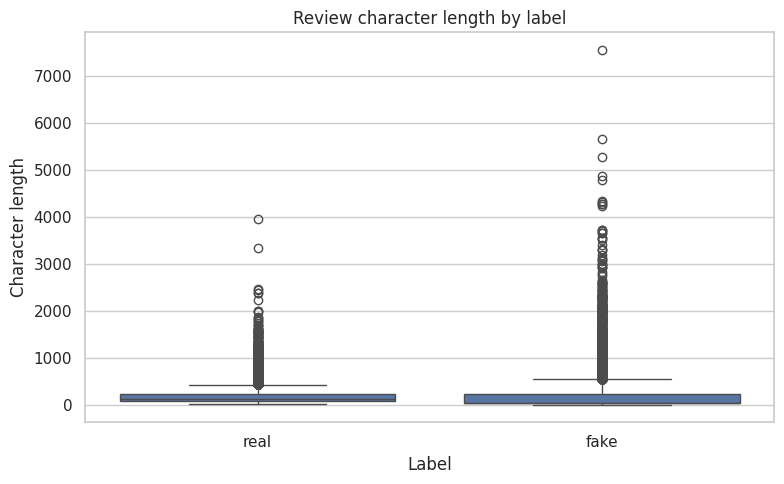

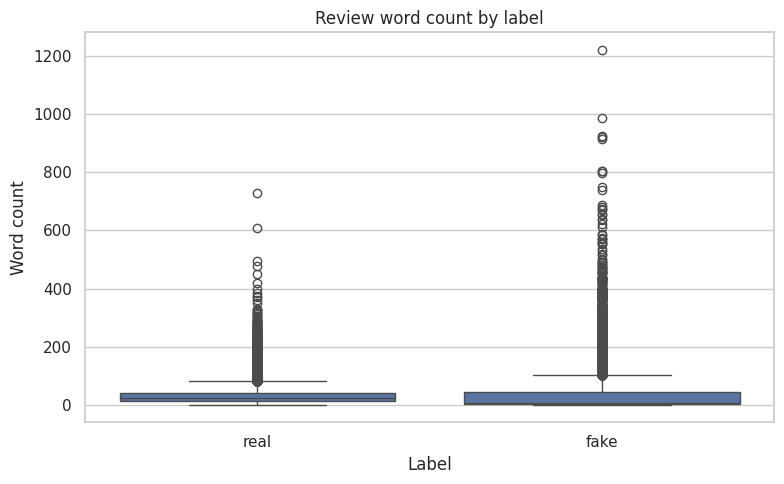

In [17]:
# if: tạo cột độ dài ký tự nếu chưa có từ bước cleaning trước
if 'review_char_len' not in clean_df.columns:
    # clean_df['review_char_len'] = clean_df[TEXT_COL].fillna('').astype(str).str.len(...: điền giá trị thay thế cho NaN
    clean_df['review_char_len'] = clean_df[TEXT_COL].fillna('').astype(str).str.len()
# if: tạo cột số từ nếu chưa có
if 'review_word_count' not in clean_df.columns:
    # clean_df['review_word_count'] = clean_df[TEXT_COL].fillna('').astype(str).str.sp...: điền giá trị thay thế cho NaN
    clean_df['review_word_count'] = clean_df[TEXT_COL].fillna('').astype(str).str.split().str.len()

# length_by_label: thống kê độ dài review theo từng nhãn (EDA-01)
length_by_label = (
    # clean_df: thực thi lệnh Python
    clean_df
    # .groupby('label_name'): nhóm dữ liệu theo cột
    .groupby('label_name')
    # .agg(: thực thi lệnh Python
    .agg(
        # review_count = ...: gán giá trị cho biến review count
        review_count=(TEXT_COL, 'size'),
        # char_len_mean = ...: tính trung bình
        char_len_mean=('review_char_len', 'mean'),
        # char_len_median = ...: tính trung vị
        char_len_median=('review_char_len', 'median'),
        # char_len_std = ...: đếm số phần tử
        char_len_std=('review_char_len', 'std'),
        # word_count_mean = ...: tính trung bình
        word_count_mean=('review_word_count', 'mean'),
        # word_count_median = ...: tính trung vị
        word_count_median=('review_word_count', 'median'),
        # word_count_std = ...: gán giá trị cho biến word count std
        word_count_std=('review_word_count', 'std'),
    # ): đóng ngoặc gọi hàm
    )
    # .reset_index(): tạo tập hợp
    .reset_index()
# ): đóng ngoặc gọi hàm
)
# length_by_label_path: đường dẫn lưu bảng thống kê độ dài theo nhãn
length_by_label_path = REPORT_TABLE_DIR / 'phase1_length_by_label.csv'
# to_csv: xuất bảng thống kê ra CSV
length_by_label.to_csv(length_by_label_path, index=False)
# record_advanced_artifact: ghi nhận artifact EDA-01 dạng bảng
record_advanced_artifact('EDA-01', 'table', length_by_label_path)
# display(length_by_label): hiển thị bảng/kết quả trên notebook
display(length_by_label)

# fig, ax = plt.subplots: tạo boxplot độ dài ký tự theo nhãn
fig, ax = plt.subplots(figsize=(8, 5))
# sns.boxplot: vẽ phân phối độ dài ký tự theo label_name
sns.boxplot(data=clean_df, x='label_name', y='review_char_len', ax=ax)
# ax.set_title('Review character length by label'): đếm số phần tử
ax.set_title('Review character length by label')
# ax.set_xlabel('Label'): tạo tập hợp
ax.set_xlabel('Label')
# ax.set_ylabel('Character length'): đếm số phần tử
ax.set_ylabel('Character length')
# plt.tight_layout(): tự chỉnh lề biểu đồ
plt.tight_layout()
# length_boxplot_path: đường dẫn lưu hình boxplot độ dài ký tự
length_boxplot_path = REPORT_FIGURE_DIR / 'phase1_length_by_label_boxplot.png'
# plt.savefig: lưu hình boxplot ký tự ra PNG
plt.savefig(length_boxplot_path, dpi=160, bbox_inches='tight')
# plt.show(): hiển thị biểu đồ
plt.show()
# record_advanced_artifact('EDA-01', 'figure', length_boxplot_path): đếm số phần tử
record_advanced_artifact('EDA-01', 'figure', length_boxplot_path)

# fig, ax: tạo boxplot số từ theo nhãn
fig, ax = plt.subplots(figsize=(8, 5))
# sns.boxplot: vẽ phân phối số từ theo label_name
sns.boxplot(data=clean_df, x='label_name', y='review_word_count', ax=ax)
# ax.set_title('Review word count by label'): tạo tập hợp
ax.set_title('Review word count by label')
# ax.set_xlabel('Label'): tạo tập hợp
ax.set_xlabel('Label')
# ax.set_ylabel('Word count'): tạo tập hợp
ax.set_ylabel('Word count')
# plt.tight_layout(): tự chỉnh lề biểu đồ
plt.tight_layout()
# word_count_boxplot_path = ...: gán giá trị cho biến word count boxplot path
word_count_boxplot_path = REPORT_FIGURE_DIR / 'phase1_word_count_by_label_boxplot.png'
# plt.savefig(word_count_boxplot_path, dpi=160, bbox_inches='tight'): lưu biểu đồ ra file hình
plt.savefig(word_count_boxplot_path, dpi=160, bbox_inches='tight')
# plt.show(): hiển thị biểu đồ
plt.show()
# record_advanced_artifact('EDA-01', 'figure', word_count_boxplot_path): thực thi lệnh Python
record_advanced_artifact('EDA-01', 'figure', word_count_boxplot_path)


### EDA-02 and EDA-03 - Sample Reviews and Sentiment by Label

Samples provide qualitative checks. Sentiment is exploratory evidence only and must not be treated as a standalone label.


/tmp/ipykernel_629/295838238.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.sample(n=min(SAMPLE_PER_CLASS, len(group)), random_state=SEED))


,label_name,label_binary,text,rating,asin,user_id,timestamp
0,fake,1,Great product for healing scars and for skin conditions of any kind. Highly recommend. This last order came with a...,4,B01BJCLNIA,AH4FINFRYIWY253JETN3OW74VCJA,7/11/2017 19:06
1,fake,1,It’s perfect for my urban decay products...,5,B015IHU77U,AEXYY77QJKADYHYSLQPIULPUGHGA,11/9/2017 9:33
2,fake,1,"Since 2008, when I discovered Nutracine after using the top brands in skincare from doctor endorsed to the most expe...",5,B07T6BCY83,AFOWZ5JQ42WONMBPFJ2ETB2WSFEA,9/29/2019 18:00
3,fake,1,I love this product,5,B001T88N0G,AGZT7JRZVAEUBOXQEEAB56QZ4K4Q,2/26/2019 22:26
4,fake,1,Dried out quickly,2,B08HWB3LFT,AEL5IL3KAUJTLGUOA6BDVHDLRTLQ,6/3/2021 11:33
5,fake,1,Small gutts well,5,B099BLC99J,AGIRJACFNQD5FHRSJVT7JGHGNFUA,2/6/2023 16:13
6,fake,1,best ever,5,B075RB3XJV,AFHTZSC5OVLMIDIFHJD6VYDXU7UQ,5/10/2019 1:00
7,fake,1,"These face/body crayons are very faint. Some of the darker colors are more visible on the skin, but for the most par...",3,B09LLR47SQ,AEX5VTQKWP3RA7CHRULGZGTUBSOA,3/19/2022 11:40
8,fake,1,"My daughter bought this for me last week. It is such a great idea, and it was available in hard-to-find gray. I open...",1,B07CZBVBHC,AGGQYVZMKD4HKVJFJR5AEKC35LCA,2/18/2019 17:13
9,fake,1,Pretty bounce looks great,5,B08J4GQ59Y,AHNFQY2L4S73RJ6ENZ7RA7FQHU2Q,1/31/2021 10:46


,label_name,review_count,sentiment_compound_mean,sentiment_compound_median,sentiment_positive_mean,sentiment_neutral_mean,sentiment_negative_mean,sentiment_backend
0,fake,17494,0.455828,0.6238,0.301270,0.648303,0.049168,nltk_vader
1,real,25255,0.445365,0.6369,0.215833,0.732283,0.051883,nltk_vader


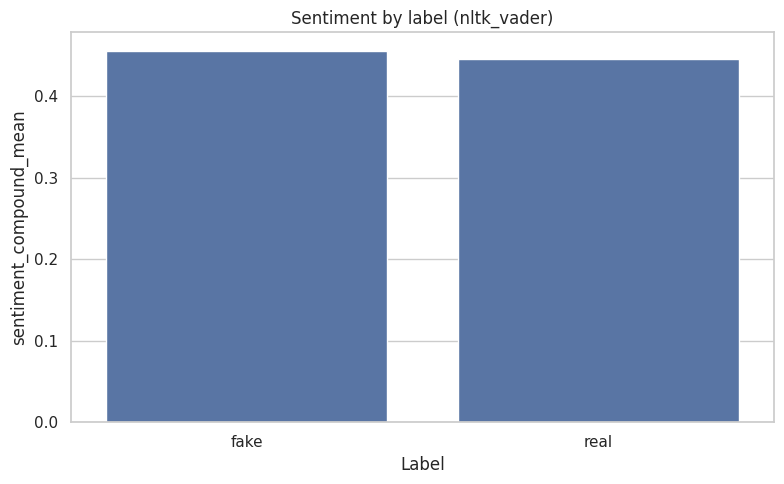

In [18]:
# sample_columns: danh sách cột hiển thị trong bảng mẫu review (chỉ lấy cột có trong clean_df)
sample_columns = [
    # col for col in [: thực thi lệnh Python
    col for col in [
        # 'label_name', LABEL_BINARY_COL, TEXT_COL, RATING_ANALYSIS_COL,: thực thi lệnh Python
        'label_name', LABEL_BINARY_COL, TEXT_COL, RATING_ANALYSIS_COL,
        # PRODUCT_ANALYSIS_COL, REVIEWER_ANALYSIS_COL, TIMESTAMP_ANALYSIS_COL,: thực thi lệnh Python
        PRODUCT_ANALYSIS_COL, REVIEWER_ANALYSIS_COL, TIMESTAMP_ANALYSIS_COL,
    # ]: đóng khối danh sách
    ]
    # if: kiểm tra điều kiện — if col is not None and col in clean_df.columns
    if col is not None and col in clean_df.columns
# ]: đóng khối danh sách
]
# sample_reviews_by_label: lấy mẫu ngẫu nhiên SAMPLE_PER_CLASS review mỗi nhãn (EDA-02)
sample_reviews_by_label = (
    # clean_df: thực thi lệnh Python
    clean_df
    # .groupby('label_name', group_keys=False): nhóm dữ liệu theo cột
    .groupby('label_name', group_keys=False)
    # .apply(lambda group: group.sample(n=min(SAMPLE_PER_CLASS, len(group)), random_st...: đếm số phần tử
    .apply(lambda group: group.sample(n=min(SAMPLE_PER_CLASS, len(group)), random_state=SEED))
    # .reset_index(drop=True): tạo tập hợp
    .reset_index(drop=True)
# ): đóng ngoặc gọi hàm
)
# sample_reviews_by_label = ...: gán giá trị cho biến sample reviews by label
sample_reviews_by_label = sample_reviews_by_label[sample_columns]
# sample_reviews_path: đường dẫn lưu bảng mẫu review theo nhãn
sample_reviews_path = REPORT_TABLE_DIR / 'phase1_samples_by_label.csv'
# sample_reviews_by_label.to_csv(sample_reviews_path, index=False): ghi DataFrame ra file CSV
sample_reviews_by_label.to_csv(sample_reviews_path, index=False)
# record_advanced_artifact('EDA-02', 'table', sample_reviews_path, note='Contains ...: thực thi lệnh Python
record_advanced_artifact('EDA-02', 'table', sample_reviews_path, note='Contains raw review text.')
# display(sample_reviews_by_label): hiển thị bảng/kết quả trên notebook
display(sample_reviews_by_label)

# sentiment_backend: tên thư viện sentiment sẽ dùng (VADER/TextBlob)
sentiment_backend = None
# sentiment_note = ...: gán giá trị cho biến sentiment note
sentiment_note = ''
# try: thử import VADER từ vaderSentiment trước
try:
    # from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer: import thư viện vaderSentiment
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    # vader_analyzer = ...: gán giá trị cho biến vader analyzer
    vader_analyzer = SentimentIntensityAnalyzer()
    # sentiment_backend = ...: gán giá trị cho biến sentiment backend
    sentiment_backend = 'vaderSentiment'
# except: xử lý ngoại lệ — except Exception as vader_import_error:
except Exception as vader_import_error:
    # try: bắt đầu khối thử/catch ngoại lệ
    try:
        # import nltk: import thư viện nltk
        import nltk
        # from nltk.sentiment import SentimentIntensityAnalyzer: import thư viện nltk
        from nltk.sentiment import SentimentIntensityAnalyzer
        # try: bắt đầu khối thử/catch ngoại lệ
        try:
            # nltk.data.find('sentiment/vader_lexicon.zip'): ghép song song nhiều iterable
            nltk.data.find('sentiment/vader_lexicon.zip')
        # except: xử lý ngoại lệ — except LookupError:
        except LookupError:
            # nltk.download('vader_lexicon', quiet=True): thực thi lệnh Python
            nltk.download('vader_lexicon', quiet=True)
        # vader_analyzer = ...: gán giá trị cho biến vader analyzer
        vader_analyzer = SentimentIntensityAnalyzer()
        # sentiment_backend = ...: gán giá trị cho biến sentiment backend
        sentiment_backend = 'nltk_vader'
    # except: xử lý ngoại lệ — except Exception as nltk_vader_error:
    except Exception as nltk_vader_error:
        # try: bắt đầu khối thử/catch ngoại lệ
        try:
            # from textblob import TextBlob: import thư viện textblob
            from textblob import TextBlob
            # sentiment_backend = ...: gán giá trị cho biến sentiment backend
            sentiment_backend = 'TextBlob'
        # except: xử lý ngoại lệ — except Exception as textblob_error:
        except Exception as textblob_error:
            # sentiment_note = ...: gán giá trị cho biến sentiment note
            sentiment_note = (
                # f'VADER unavailable: {vader_import_error}; ': thực thi lệnh Python
                f'VADER unavailable: {vader_import_error}; '
                # f'NLTK VADER unavailable: {nltk_vader_error}; ': thực thi lệnh Python
                f'NLTK VADER unavailable: {nltk_vader_error}; '
                # f'TextBlob unavailable: {textblob_error}': thực thi lệnh Python
                f'TextBlob unavailable: {textblob_error}'
            # ): đóng ngoặc gọi hàm
            )

# sentiment_frame = ...: gán giá trị cho biến sentiment frame
sentiment_frame = clean_df[['label_name', TEXT_COL]].copy()
# sentiment_frame['_review_text_for_sentiment'] = sentiment_frame[TEXT_COL].fillna...: điền giá trị thay thế cho NaN
sentiment_frame['_review_text_for_sentiment'] = sentiment_frame[TEXT_COL].fillna('').astype(str)

# if: kiểm tra điều kiện — if sentiment_backend in {'vaderSentiment', 'nltk_vader'}:
if sentiment_backend in {'vaderSentiment', 'nltk_vader'}:
    # vader_scores = ...: gán giá trị cho biến vader scores
    vader_scores = sentiment_frame['_review_text_for_sentiment'].map(vader_analyzer.polarity_scores)
    # sentiment_frame['sentiment_compound'] = vader_scores.map(lambda score: score['co...: thực thi lệnh Python
    sentiment_frame['sentiment_compound'] = vader_scores.map(lambda score: score['compound'])
    # sentiment_frame['sentiment_positive'] = vader_scores.map(lambda score: score['po...: thực thi lệnh Python
    sentiment_frame['sentiment_positive'] = vader_scores.map(lambda score: score['pos'])
    # sentiment_frame['sentiment_neutral'] = vader_scores.map(lambda score: score['neu...: thực thi lệnh Python
    sentiment_frame['sentiment_neutral'] = vader_scores.map(lambda score: score['neu'])
    # sentiment_frame['sentiment_negative'] = vader_scores.map(lambda score: score['ne...: thực thi lệnh Python
    sentiment_frame['sentiment_negative'] = vader_scores.map(lambda score: score['neg'])
    # sentiment_by_label = ...: gán giá trị cho biến sentiment by label
    sentiment_by_label = (
        # sentiment_frame.groupby('label_name'): nhóm dữ liệu theo cột
        sentiment_frame.groupby('label_name')
        # .agg(: thực thi lệnh Python
        .agg(
            # review_count = ...: gán giá trị cho biến review count
            review_count=(TEXT_COL, 'size'),
            # sentiment_compound_mean = ...: tính trung bình
            sentiment_compound_mean=('sentiment_compound', 'mean'),
            # sentiment_compound_median = ...: tính trung vị
            sentiment_compound_median=('sentiment_compound', 'median'),
            # sentiment_positive_mean = ...: tính trung bình
            sentiment_positive_mean=('sentiment_positive', 'mean'),
            # sentiment_neutral_mean = ...: tính trung bình
            sentiment_neutral_mean=('sentiment_neutral', 'mean'),
            # sentiment_negative_mean = ...: tính trung bình
            sentiment_negative_mean=('sentiment_negative', 'mean'),
        # ): đóng ngoặc gọi hàm
        )
        # .reset_index(): tạo tập hợp
        .reset_index()
    # ): đóng ngoặc gọi hàm
    )
    # plot_col = ...: tính trung bình
    plot_col = 'sentiment_compound_mean'
# elif: nhánh điều kiện phụ — elif sentiment_backend == 'TextBlob':
elif sentiment_backend == 'TextBlob':
    # sentiment_frame['sentiment_polarity'] = sentiment_frame['_review_text_for_sentim...: thực thi lệnh Python
    sentiment_frame['sentiment_polarity'] = sentiment_frame['_review_text_for_sentiment'].map(lambda text: TextBlob(text).sentiment.polarity)
    # sentiment_frame['sentiment_subjectivity'] = sentiment_frame['_review_text_for_se...: thực thi lệnh Python
    sentiment_frame['sentiment_subjectivity'] = sentiment_frame['_review_text_for_sentiment'].map(lambda text: TextBlob(text).sentiment.subjectivity)
    # sentiment_by_label = ...: gán giá trị cho biến sentiment by label
    sentiment_by_label = (
        # sentiment_frame.groupby('label_name'): nhóm dữ liệu theo cột
        sentiment_frame.groupby('label_name')
        # .agg(: thực thi lệnh Python
        .agg(
            # review_count = ...: gán giá trị cho biến review count
            review_count=(TEXT_COL, 'size'),
            # sentiment_polarity_mean = ...: tính trung bình
            sentiment_polarity_mean=('sentiment_polarity', 'mean'),
            # sentiment_polarity_median = ...: tính trung vị
            sentiment_polarity_median=('sentiment_polarity', 'median'),
            # sentiment_subjectivity_mean = ...: tính trung bình
            sentiment_subjectivity_mean=('sentiment_subjectivity', 'mean'),
        # ): đóng ngoặc gọi hàm
        )
        # .reset_index(): tạo tập hợp
        .reset_index()
    # ): đóng ngoặc gọi hàm
    )
    # plot_col = ...: tính trung bình
    plot_col = 'sentiment_polarity_mean'
# else: nhánh còn lại của điều kiện
else:
    # sentiment_by_label = ...: gán giá trị cho biến sentiment by label
    sentiment_by_label = pd.DataFrame([{
        # 'label_name': 'skipped',: thực thi lệnh Python
        'label_name': 'skipped',
        # 'review_count': 0,: thực thi lệnh Python
        'review_count': 0,
        # 'sentiment_backend': 'unavailable',: thực thi lệnh Python
        'sentiment_backend': 'unavailable',
        # 'note': sentiment_note,: thực thi lệnh Python
        'note': sentiment_note,
    # }]): đóng khối cú pháp Python
    }])
    # plot_col = ...: gán giá trị cho biến plot col
    plot_col = None

# sentiment_by_label['sentiment_backend'] = sentiment_backend or 'unavailable': thực thi lệnh Python
sentiment_by_label['sentiment_backend'] = sentiment_backend or 'unavailable'
# sentiment_path = ...: gán giá trị cho biến sentiment path
sentiment_path = REPORT_TABLE_DIR / 'phase1_sentiment_by_label.csv'
# sentiment_by_label.to_csv(sentiment_path, index=False): ghi DataFrame ra file CSV
sentiment_by_label.to_csv(sentiment_path, index=False)
# record_advanced_artifact('EDA-03', 'table', sentiment_path, status='generated' i...: thực thi lệnh Python
record_advanced_artifact('EDA-03', 'table', sentiment_path, status='generated' if sentiment_backend else 'skipped', note=sentiment_note)
# display(sentiment_by_label): hiển thị bảng/kết quả trên notebook
display(sentiment_by_label)

# fig, ax = plt.subplots(figsize=(8, 5)): thực thi lệnh Python
fig, ax = plt.subplots(figsize=(8, 5))
# if: kiểm tra điều kiện — if plot_col is not None:
if plot_col is not None:
    # sns.barplot(data=sentiment_by_label, x='label_name', y=plot_col, ax=ax): vẽ barplot seaborn
    sns.barplot(data=sentiment_by_label, x='label_name', y=plot_col, ax=ax)
    # ax.set_title(f'Sentiment by label ({sentiment_backend})'): tạo tập hợp
    ax.set_title(f'Sentiment by label ({sentiment_backend})')
    # ax.set_xlabel('Label'): tạo tập hợp
    ax.set_xlabel('Label')
    # ax.set_ylabel(plot_col): tạo tập hợp
    ax.set_ylabel(plot_col)
# else: nhánh còn lại của điều kiện
else:
    # ax.text(0.5, 0.5, 'Sentiment backend unavailable', ha='center', va='center'): thực thi lệnh Python
    ax.text(0.5, 0.5, 'Sentiment backend unavailable', ha='center', va='center')
    # ax.set_axis_off(): tạo tập hợp
    ax.set_axis_off()
# plt.tight_layout(): tự chỉnh lề biểu đồ
plt.tight_layout()
# sentiment_figure_path = ...: gán giá trị cho biến sentiment figure path
sentiment_figure_path = REPORT_FIGURE_DIR / 'phase1_sentiment_by_label.png'
# plt.savefig(sentiment_figure_path, dpi=160, bbox_inches='tight'): lưu biểu đồ ra file hình
plt.savefig(sentiment_figure_path, dpi=160, bbox_inches='tight')
# plt.show(): hiển thị biểu đồ
plt.show()
# record_advanced_artifact('EDA-03', 'figure', sentiment_figure_path, status='gene...: thực thi lệnh Python
record_advanced_artifact('EDA-03', 'figure', sentiment_figure_path, status='generated' if sentiment_backend else 'skipped', note=sentiment_note)


### EDA-04 - Word Frequency, N-Grams, and Optional Word Cloud

Lexical EDA surfaces class-specific terms. Vectorization is capped to reduce RAM use in Colab.


,label_name,ngram,count,ngram_size,rank,note
0,fake,br,6272,1,1,
1,fake,hair,4501,1,2,
2,fake,product,3829,1,3,
3,fake,great,3518,1,4,
4,fake,like,3467,1,5,
5,fake,love,3128,1,6,
6,fake,use,3068,1,7,
7,fake,good,2473,1,8,
8,fake,just,2321,1,9,
9,fake,skin,2310,1,10,


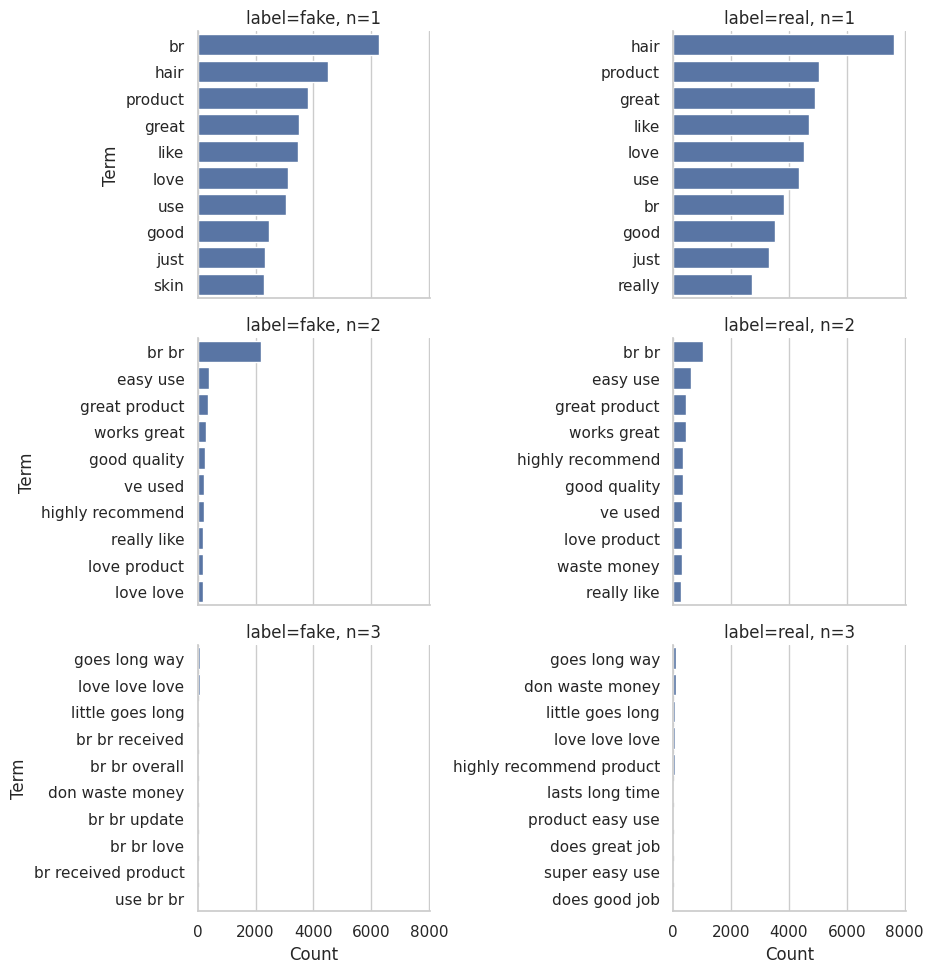

ENABLE_WORDCLOUD is False by default.


In [19]:
# from sklearn...CountVectorizer: vector hóa text thành bag-of-words/n-grams
from sklearn.feature_extraction.text import CountVectorizer


# get_top_ngrams_by_label: trích top n-gram phổ biến theo từng nhãn (EDA-04)
def get_top_ngrams_by_label(frame, text_col, label_col, ngram_range, top_n=30):
    # rows = ...: gán giá trị cho biến rows
    rows = []
    # ngram_size = ...: tạo dãy số cho vòng lặp
    ngram_size = ngram_range[0]
    # for: vòng lặp — for label_name, group in frame.groupby(label_col):
    for label_name, group in frame.groupby(label_col):
        # texts = ...: điền giá trị thay thế cho NaN
        texts = group[text_col].fillna('').astype(str)
        # try: bắt đầu khối thử/catch ngoại lệ
        try:
            # vectorizer = ...: gán giá trị cho biến vectorizer
            vectorizer = CountVectorizer(
                # stop_words = ...: gán giá trị cho biến stop words
                stop_words='english',
                # lowercase = ...: gán giá trị cho biến lowercase
                lowercase=True,
                # min_df = ...: lấy giá trị nhỏ nhất
                min_df=2,
                # max_features = ...: lấy giá trị lớn nhất
                max_features=5000,  # max_features=5000 for RAM-bounded Colab EDA
                # ngram_range = ...: tạo dãy số cho vòng lặp
                ngram_range=ngram_range,
            # ): đóng ngoặc gọi hàm
            )
            # matrix = ...: fit scaler trên train và transform
            matrix = vectorizer.fit_transform(texts)
            # counts = ...: tính tổng
            counts = np.asarray(matrix.sum(axis=0)).ravel()
            # terms = ...: gán giá trị cho biến terms
            terms = vectorizer.get_feature_names_out()
        # except: xử lý ngoại lệ — except ValueError as exc:
        except ValueError as exc:
            # rows.append({: thực thi lệnh Python
            rows.append({
                # 'label_name': label_name,: thực thi lệnh Python
                'label_name': label_name,
                # 'ngram': '__skipped__',: thực thi lệnh Python
                'ngram': '__skipped__',
                # 'count': 0,: thực thi lệnh Python
                'count': 0,
                # 'ngram_size': ngram_size,: thực thi lệnh Python
                'ngram_size': ngram_size,
                # 'rank': 1,: thực thi lệnh Python
                'rank': 1,
                # 'note': str(exc),: ép kiểu chuỗi
                'note': str(exc),
            # }): đóng từ điển hoặc DataFrame constructor
            })
            continue
        # order = ...: gán giá trị cho biến order
        order = counts.argsort()[::-1][:top_n]
        # for: vòng lặp — for rank, idx in enumerate(order, start=1):
        for rank, idx in enumerate(order, start=1):
            # rows.append({: thực thi lệnh Python
            rows.append({
                # 'label_name': label_name,: thực thi lệnh Python
                'label_name': label_name,
                # 'ngram': terms[idx],: thực thi lệnh Python
                'ngram': terms[idx],
                # 'count': int(counts[idx]),: ép kiểu số nguyên
                'count': int(counts[idx]),
                # 'ngram_size': ngram_size,: thực thi lệnh Python
                'ngram_size': ngram_size,
                # 'rank': rank,: thực thi lệnh Python
                'rank': rank,
                # 'note': '',: thực thi lệnh Python
                'note': '',
            # }): đóng từ điển hoặc DataFrame constructor
            })
    # return: trả kết quả từ hàm
    return pd.DataFrame(rows)


# top_term_frames: gọi hàm cho unigram, bigram, trigram
top_term_frames = [
    # get_top_ngrams_by_label(clean_df, TEXT_COL, 'label_name', (1, 1), TOP_TERMS),: thực thi lệnh Python
    get_top_ngrams_by_label(clean_df, TEXT_COL, 'label_name', (1, 1), TOP_TERMS),
    # get_top_ngrams_by_label(clean_df, TEXT_COL, 'label_name', (2, 2), TOP_TERMS),: thực thi lệnh Python
    get_top_ngrams_by_label(clean_df, TEXT_COL, 'label_name', (2, 2), TOP_TERMS),
    # get_top_ngrams_by_label(clean_df, TEXT_COL, 'label_name', (3, 3), TOP_TERMS),: thực thi lệnh Python
    get_top_ngrams_by_label(clean_df, TEXT_COL, 'label_name', (3, 3), TOP_TERMS),
# ]: đóng khối danh sách
]
# top_terms_by_label: gộp kết quả 3 loại n-gram
top_terms_by_label = pd.concat(top_term_frames, ignore_index=True)
# top_terms_path: đường dẫn lưu bảng top terms theo nhãn
top_terms_path = REPORT_TABLE_DIR / 'phase1_top_terms_by_label.csv'
# top_terms_by_label.to_csv(top_terms_path, index=False): ghi DataFrame ra file CSV
top_terms_by_label.to_csv(top_terms_path, index=False)
# record_advanced_artifact('EDA-04', 'table', top_terms_path): thực thi lệnh Python
record_advanced_artifact('EDA-04', 'table', top_terms_path)
# display(top_terms_by_label.head(30)): hiển thị bảng/kết quả trên notebook
display(top_terms_by_label.head(30))

# plot_terms = ...: gán giá trị cho biến plot terms
plot_terms = (
    # top_terms_by_label[top_terms_by_label['ngram'] != '__skipped__']: thực thi lệnh Python
    top_terms_by_label[top_terms_by_label['ngram'] != '__skipped__']
    # .sort_values(['label_name', 'ngram_size', 'rank']): thực thi lệnh Python
    .sort_values(['label_name', 'ngram_size', 'rank'])
    # .groupby(['label_name', 'ngram_size'], group_keys=False): nhóm dữ liệu theo cột
    .groupby(['label_name', 'ngram_size'], group_keys=False)
    # .head(10): xem vài dòng đầu
    .head(10)
# ): đóng ngoặc gọi hàm
)
# if: kiểm tra điều kiện — if len(plot_terms) > 0:
if len(plot_terms) > 0:
    # g = ...: vẽ faceted categorical plot
    g = sns.catplot(
        # data = ...: gán giá trị cho biến data
        data=plot_terms,
        # kind = ...: gán giá trị cho biến kind
        kind='bar',
        # x = ...: gán giá trị cho biến x
        x='count',
        # y = ...: gán giá trị cho biến y
        y='ngram',
        # col = ...: gán giá trị cho biến col
        col='label_name',
        # row = ...: gán giá trị cho biến row
        row='ngram_size',
        # sharey = ...: gán giá trị cho biến sharey
        sharey=False,
        # height = ...: gán giá trị cho biến height
        height=3.3,
        # aspect = ...: gán giá trị cho biến aspect
        aspect=1.4,
    # ): đóng ngoặc gọi hàm
    )
    # g.set_titles('label={col_name}, n={row_name}'): tạo tập hợp
    g.set_titles('label={col_name}, n={row_name}')
    # g.set_axis_labels('Count', 'Term'): tạo tập hợp
    g.set_axis_labels('Count', 'Term')
    # top_terms_figure_path = ...: gán giá trị cho biến top terms figure path
    top_terms_figure_path = REPORT_FIGURE_DIR / 'phase1_top_terms_by_label.png'
    # plt.tight_layout(): tự chỉnh lề biểu đồ
    plt.tight_layout()
    # plt.savefig(top_terms_figure_path, dpi=160, bbox_inches='tight'): lưu biểu đồ ra file hình
    plt.savefig(top_terms_figure_path, dpi=160, bbox_inches='tight')
    # plt.show(): hiển thị biểu đồ
    plt.show()
# else: nhánh còn lại của điều kiện
else:
    # fig, ax = plt.subplots(figsize=(8, 4)): thực thi lệnh Python
    fig, ax = plt.subplots(figsize=(8, 4))
    # ax.text(0.5, 0.5, 'No n-gram terms available', ha='center', va='center'): thực thi lệnh Python
    ax.text(0.5, 0.5, 'No n-gram terms available', ha='center', va='center')
    # ax.set_axis_off(): tạo tập hợp
    ax.set_axis_off()
    # top_terms_figure_path = ...: gán giá trị cho biến top terms figure path
    top_terms_figure_path = REPORT_FIGURE_DIR / 'phase1_top_terms_by_label.png'
    # plt.savefig(top_terms_figure_path, dpi=160, bbox_inches='tight'): lưu biểu đồ ra file hình
    plt.savefig(top_terms_figure_path, dpi=160, bbox_inches='tight')
    # plt.show(): hiển thị biểu đồ
    plt.show()
# record_advanced_artifact('EDA-04', 'figure', top_terms_figure_path): thực thi lệnh Python
record_advanced_artifact('EDA-04', 'figure', top_terms_figure_path)

# wordcloud_status = ...: gán giá trị cho biến wordcloud status
wordcloud_status = 'skipped'
# wordcloud_note = ...: gán giá trị cho biến wordcloud note
wordcloud_note = 'ENABLE_WORDCLOUD is False by default.'
# if: kiểm tra điều kiện — if ENABLE_WORDCLOUD:
if ENABLE_WORDCLOUD:
    # try: bắt đầu khối thử/catch ngoại lệ
    try:
        # from wordcloud import STOPWORDS, WordCloud: import thư viện wordcloud
        from wordcloud import STOPWORDS, WordCloud
        # for: vòng lặp — for label_name, group in clean_df.groupby('label_name'):
        for label_name, group in clean_df.groupby('label_name'):
            # text_blob = ...: điền giá trị thay thế cho NaN
            text_blob = ' '.join(group[TEXT_COL].fillna('').astype(str).tolist())
            # wordcloud = ...: gán giá trị cho biến wordcloud
            wordcloud = WordCloud(
                # width = ...: gán giá trị cho biến width
                width=1200,
                # height = ...: gán giá trị cho biến height
                height=700,
                # background_color = ...: làm tròn số
                background_color='white',
                # stopwords = ...: gán giá trị cho biến stopwords
                stopwords=STOPWORDS,
                # max_words = ...: lấy giá trị lớn nhất
                max_words=150,
            # ).generate(text_blob): thực thi lệnh Python
            ).generate(text_blob)
            # safe_label = ...: ép kiểu chuỗi
            safe_label = re.sub(r'[^a-zA-Z0-9_]+', '_', str(label_name).lower()).strip('_')
            # wordcloud_path = ...: gán giá trị cho biến wordcloud path
            wordcloud_path = REPORT_FIGURE_DIR / f'phase1_wordcloud_{safe_label}.png'
            # fig, ax = plt.subplots(figsize=(10, 6)): thực thi lệnh Python
            fig, ax = plt.subplots(figsize=(10, 6))
            # ax.imshow(wordcloud, interpolation='bilinear'): ép kiểu số nguyên
            ax.imshow(wordcloud, interpolation='bilinear')
            # ax.set_axis_off(): tạo tập hợp
            ax.set_axis_off()
            # ax.set_title(f'Word cloud - {label_name}'): tạo tập hợp
            ax.set_title(f'Word cloud - {label_name}')
            # plt.tight_layout(): tự chỉnh lề biểu đồ
            plt.tight_layout()
            # plt.savefig(wordcloud_path, dpi=160, bbox_inches='tight'): lưu biểu đồ ra file hình
            plt.savefig(wordcloud_path, dpi=160, bbox_inches='tight')
            # plt.show(): hiển thị biểu đồ
            plt.show()
            # record_advanced_artifact('EDA-04', 'figure', wordcloud_path): thực thi lệnh Python
            record_advanced_artifact('EDA-04', 'figure', wordcloud_path)
        # wordcloud_status = ...: gán giá trị cho biến wordcloud status
        wordcloud_status = 'generated'
        # wordcloud_note = ...: gán giá trị cho biến wordcloud note
        wordcloud_note = ''
    # except: xử lý ngoại lệ — except Exception as exc:
    except Exception as exc:
        # wordcloud_note = ...: gán giá trị cho biến wordcloud note
        wordcloud_note = f'WordCloud unavailable or failed: {exc}'
        # print(wordcloud_note): in thông tin ra console
        print(wordcloud_note)
# else: nhánh còn lại của điều kiện
else:
    # print(wordcloud_note): in thông tin ra console
    print(wordcloud_note)
# record_advanced_artifact(: thực thi lệnh Python
record_advanced_artifact(
    # 'EDA-04',: thực thi lệnh Python
    'EDA-04',
    # 'optional_figure',: thực thi lệnh Python
    'optional_figure',
    # REPORT_FIGURE_DIR / 'phase1_wordcloud_<label_name>.png',: thực thi lệnh Python
    REPORT_FIGURE_DIR / 'phase1_wordcloud_<label_name>.png',
    # status = ...: gán giá trị cho biến status
    status=wordcloud_status,
    # note = ...: gán giá trị cho biến note
    note=wordcloud_note,
# ): đóng ngoặc gọi hàm
)


### EDA-05 to EDA-08 - Temporal, Burst, Rating, and Product-Level Analysis

These analyses inspect behavioral patterns that can guide Phase 2 features. They are EDA only; downstream train-time aggregates must avoid leakage.


,period,review_count,fake_count,fake_rate,period_type,timestamp_column,parse_rate
0,2003-09-17,1,1,1.0,date,timestamp,1.0
1,2004-01-31,1,1,1.0,date,timestamp,1.0
2,2004-05-01,1,1,1.0,date,timestamp,1.0
3,2004-06-15,1,1,1.0,date,timestamp,1.0
4,2004-06-23,1,1,1.0,date,timestamp,1.0
5,2004-10-12,1,1,1.0,date,timestamp,1.0
6,2004-11-09,1,1,1.0,date,timestamp,1.0
7,2004-12-15,1,0,0.0,date,timestamp,1.0
8,2004-12-18,1,1,1.0,date,timestamp,1.0
9,2005-01-21,1,1,1.0,date,timestamp,1.0


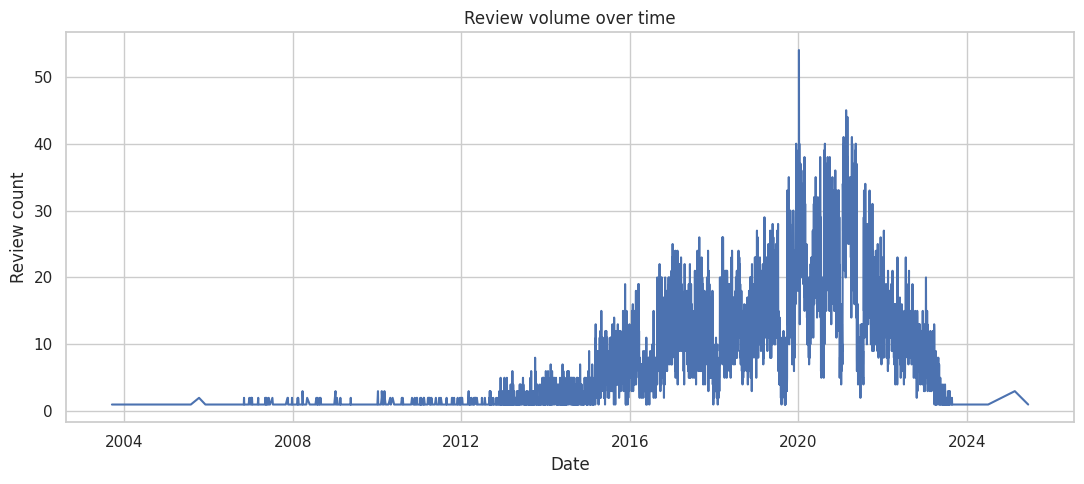

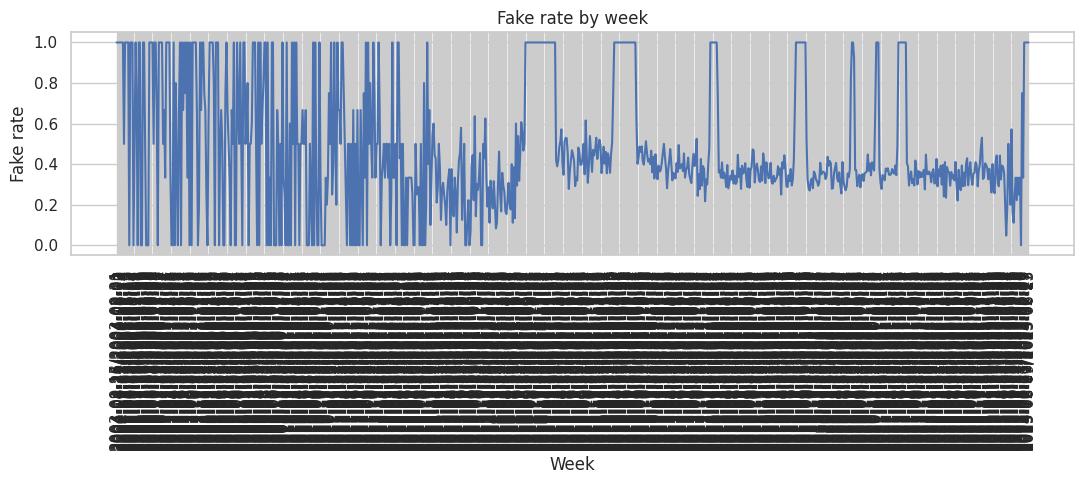

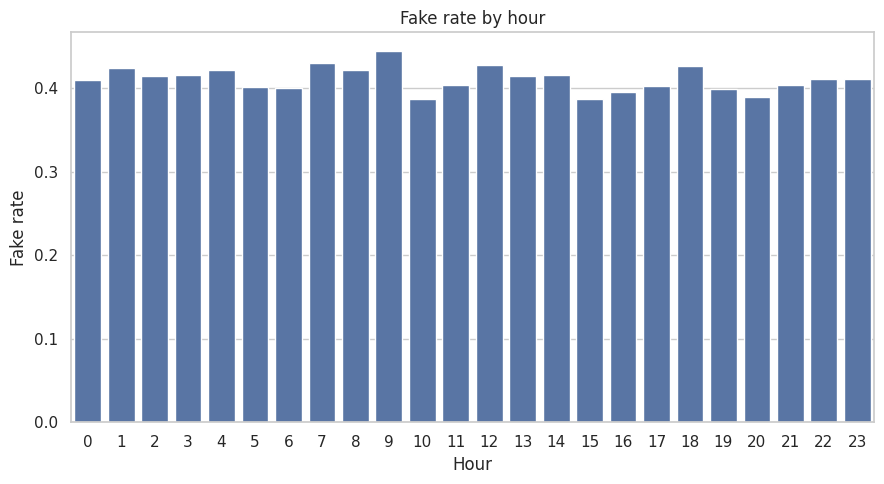

,user_id,active_days,max_daily_reviews,mean_daily_reviews,burst_fake_count,max_weekly_reviews,total_reviews,total_fake_count,fake_rate
13892,AFDYIK3FNPY2JFBQYUWC6GSBMIRQ_2,9,2,1.111111,10,2,10,10,1.000000
28896,AGROTY3KEQXC7OWGNLDMPTDPJXHA,5,2,1.200000,6,2,6,6,1.000000
14706,AFGGRGHGHSFKMZASFBYFRHBBEOPA,4,2,1.250000,5,2,5,5,1.000000
17159,AFNRGRORFAGSB7WGANETBDDYDEAQ,4,2,1.250000,5,2,5,5,1.000000
5329,AEJU3Z6HDAERETMYI2CXBQVPPDFA,3,2,1.333333,4,2,4,4,1.000000
6281,AEMP3A7IKW37CMWFXNKXWW6HGJHA_1,3,2,1.333333,4,2,4,4,1.000000
18687,AFSJ6CSPJIJLJEZZ2ZBUVLE3SDXQ,2,2,1.500000,2,2,3,2,0.666667
665,AE3VRWFW2PGAQYAIMZXS3DUHW7JQ,1,2,2.000000,1,2,2,1,0.500000
1149,AE5EJCJI7SSI3PQVCOU74A7LDFPQ,1,2,2.000000,1,2,2,1,0.500000
3582,AEESUQP2GMOKDU5VNQW7BS3MYDGA,1,2,2.000000,1,2,2,1,0.500000


In [20]:
# parse_review_datetime: chuyển cột thời gian (unix ms/s hoặc chuỗi) sang datetime
def parse_review_datetime(series):
    # pd.to_numeric: thử parse dạng số unix timestamp
    numeric = pd.to_numeric(series, errors='coerce')
    # if: kiểm tra điều kiện — if numeric.notna().mean() > 0.9:
    if numeric.notna().mean() > 0.9:
        # median_value = ...: xóa dòng/cột có giá trị thiếu
        median_value = numeric.dropna().median()
        # if: kiểm tra điều kiện — if median_value > 1e12:
        if median_value > 1e12:
            # return: trả kết quả từ hàm
            return pd.to_datetime(numeric, unit='ms', errors='coerce')
        # if: kiểm tra điều kiện — if median_value > 1e9:
        if median_value > 1e9:
            # return: trả kết quả từ hàm
            return pd.to_datetime(numeric, unit='s', errors='coerce')
    # return: trả kết quả từ hàm
    return pd.to_datetime(series, errors='coerce')


# temporal_available: kiểm tra có cột timestamp để phân tích EDA-05/06
temporal_available = TIMESTAMP_ANALYSIS_COL is not None and TIMESTAMP_ANALYSIS_COL in clean_df.columns
# if temporal_available: parse datetime và tính thống kê theo thời gian
if temporal_available:
    # temporal_df = ...: gán giá trị cho biến temporal df
    temporal_df = clean_df.copy()
    # temporal_df['_review_datetime'] = parse_review_datetime(temporal_df[TIMESTAMP_AN...: thực thi lệnh Python
    temporal_df['_review_datetime'] = parse_review_datetime(temporal_df[TIMESTAMP_ANALYSIS_COL])
    # parse_rate = ...: tính trung bình
    parse_rate = temporal_df['_review_datetime'].notna().mean()
    # temporal_valid = ...: xóa dòng/cột có giá trị thiếu
    temporal_valid = temporal_df.dropna(subset=['_review_datetime']).copy()
# else: nhánh còn lại của điều kiện
else:
    # parse_rate = ...: gán giá trị cho biến parse rate
    parse_rate = 0.0
    # temporal_valid = ...: gán giá trị cho biến temporal valid
    temporal_valid = pd.DataFrame()

# if: kiểm tra điều kiện — if temporal_available and parse_rate > 0:
if temporal_available and parse_rate > 0:
    # temporal_valid['_date'] = temporal_valid['_review_datetime'].dt.date: thực thi lệnh Python
    temporal_valid['_date'] = temporal_valid['_review_datetime'].dt.date
    # temporal_valid['_week'] = temporal_valid['_review_datetime'].dt.to_period('W').a...: ép kiểu dữ liệu cột
    temporal_valid['_week'] = temporal_valid['_review_datetime'].dt.to_period('W').astype(str)
    # temporal_valid['_day_of_week'] = temporal_valid['_review_datetime'].dt.day_name(...: thực thi lệnh Python
    temporal_valid['_day_of_week'] = temporal_valid['_review_datetime'].dt.day_name()
    # temporal_valid['_hour'] = temporal_valid['_review_datetime'].dt.hour: thực thi lệnh Python
    temporal_valid['_hour'] = temporal_valid['_review_datetime'].dt.hour

    # date_stats = ...: nhóm dữ liệu theo cột
    date_stats = temporal_valid.groupby('_date').agg(review_count=(TEXT_COL, 'size'), fake_count=('_is_fake', 'sum')).reset_index().rename(columns={'_date': 'period'})
    # week_stats = ...: nhóm dữ liệu theo cột
    week_stats = temporal_valid.groupby('_week').agg(review_count=(TEXT_COL, 'size'), fake_count=('_is_fake', 'sum')).reset_index().rename(columns={'_week': 'period'})
    # day_stats = ...: nhóm dữ liệu theo cột
    day_stats = temporal_valid.groupby('_day_of_week').agg(review_count=(TEXT_COL, 'size'), fake_count=('_is_fake', 'sum')).reset_index().rename(columns={'_day_of_week': 'period'})
    # hour_stats = ...: nhóm dữ liệu theo cột
    hour_stats = temporal_valid.groupby('_hour').agg(review_count=(TEXT_COL, 'size'), fake_count=('_is_fake', 'sum')).reset_index().rename(columns={'_hour': 'period'})
    # for: vòng lặp — for frame, period_type in [(date_stats, 'date'), (week_stats, 'week'),
    for frame, period_type in [(date_stats, 'date'), (week_stats, 'week'), (day_stats, 'day_of_week'), (hour_stats, 'hour')]:
        # frame['fake_rate'] = frame['fake_count'] / frame['review_count']: thực thi lệnh Python
        frame['fake_rate'] = frame['fake_count'] / frame['review_count']
        # frame['period_type'] = period_type: thực thi lệnh Python
        frame['period_type'] = period_type
    # temporal_stats = ...: nối nhiều DataFrame
    temporal_stats = pd.concat([date_stats, week_stats, day_stats, hour_stats], ignore_index=True)
    # temporal_stats['timestamp_column'] = TIMESTAMP_ANALYSIS_COL: thực thi lệnh Python
    temporal_stats['timestamp_column'] = TIMESTAMP_ANALYSIS_COL
    # temporal_stats['parse_rate'] = parse_rate: thực thi lệnh Python
    temporal_stats['parse_rate'] = parse_rate
    # temporal_status = ...: gán giá trị cho biến temporal status
    temporal_status = 'generated'
    # temporal_note = ...: gán giá trị cho biến temporal note
    temporal_note = ''
# else: nhánh còn lại của điều kiện
else:
    # temporal_stats = ...: gán giá trị cho biến temporal stats
    temporal_stats = pd.DataFrame([{
        # 'period_type': 'skipped',: thực thi lệnh Python
        'period_type': 'skipped',
        # 'period': '',: thực thi lệnh Python
        'period': '',
        # 'review_count': 0,: thực thi lệnh Python
        'review_count': 0,
        # 'fake_count': 0,: thực thi lệnh Python
        'fake_count': 0,
        # 'fake_rate': np.nan,: thực thi lệnh Python
        'fake_rate': np.nan,
        # 'timestamp_column': TIMESTAMP_ANALYSIS_COL,: thực thi lệnh Python
        'timestamp_column': TIMESTAMP_ANALYSIS_COL,
        # 'parse_rate': parse_rate,: thực thi lệnh Python
        'parse_rate': parse_rate,
        # 'note': 'Timestamp column missing or could not be parsed.',: thực thi lệnh Python
        'note': 'Timestamp column missing or could not be parsed.',
    # }]): đóng khối cú pháp Python
    }])
    # temporal_status = ...: gán giá trị cho biến temporal status
    temporal_status = 'skipped'
    # temporal_note = ...: gán giá trị cho biến temporal note
    temporal_note = 'Timestamp column missing or could not be parsed.'

# temporal_stats_path = ...: gán giá trị cho biến temporal stats path
temporal_stats_path = REPORT_TABLE_DIR / 'phase1_temporal_stats.csv'
# temporal_stats.to_csv(temporal_stats_path, index=False): ghi DataFrame ra file CSV
temporal_stats.to_csv(temporal_stats_path, index=False)
# record_advanced_artifact('EDA-05', 'table', temporal_stats_path, status=temporal...: thực thi lệnh Python
record_advanced_artifact('EDA-05', 'table', temporal_stats_path, status=temporal_status, note=temporal_note)
# display(temporal_stats.head(20)): hiển thị bảng/kết quả trên notebook
display(temporal_stats.head(20))

# if: kiểm tra điều kiện — if temporal_status == 'generated':
if temporal_status == 'generated':
    # date_plot = ...: gán giá trị cho biến date plot
    date_plot = date_stats.copy()
    # date_plot['period'] = pd.to_datetime(date_plot['period']): thực thi lệnh Python
    date_plot['period'] = pd.to_datetime(date_plot['period'])
    # fig, ax = plt.subplots(figsize=(11, 5)): thực thi lệnh Python
    fig, ax = plt.subplots(figsize=(11, 5))
    # sns.lineplot(data=date_plot, x='period', y='review_count', ax=ax): vẽ line plot seaborn
    sns.lineplot(data=date_plot, x='period', y='review_count', ax=ax)
    # ax.set_title('Review volume over time'): tạo tập hợp
    ax.set_title('Review volume over time')
    # ax.set_xlabel('Date'): tạo tập hợp
    ax.set_xlabel('Date')
    # ax.set_ylabel('Review count'): tạo tập hợp
    ax.set_ylabel('Review count')
    # plt.tight_layout(): tự chỉnh lề biểu đồ
    plt.tight_layout()
    # review_volume_path = ...: gán giá trị cho biến review volume path
    review_volume_path = REPORT_FIGURE_DIR / 'phase1_review_volume_over_time.png'
    # plt.savefig(review_volume_path, dpi=160, bbox_inches='tight'): lưu biểu đồ ra file hình
    plt.savefig(review_volume_path, dpi=160, bbox_inches='tight')
    # plt.show(): hiển thị biểu đồ
    plt.show()
    # record_advanced_artifact('EDA-05', 'figure', review_volume_path): thực thi lệnh Python
    record_advanced_artifact('EDA-05', 'figure', review_volume_path)

    # fig, ax = plt.subplots(figsize=(11, 5)): thực thi lệnh Python
    fig, ax = plt.subplots(figsize=(11, 5))
    # sns.lineplot(data=week_stats, x='period', y='fake_rate', ax=ax): vẽ line plot seaborn
    sns.lineplot(data=week_stats, x='period', y='fake_rate', ax=ax)
    # ax.set_title('Fake rate by week'): tạo tập hợp
    ax.set_title('Fake rate by week')
    # ax.set_xlabel('Week'): tạo tập hợp
    ax.set_xlabel('Week')
    # ax.set_ylabel('Fake rate'): tạo tập hợp
    ax.set_ylabel('Fake rate')
    # ax.tick_params(axis='x', rotation=90): thực thi lệnh Python
    ax.tick_params(axis='x', rotation=90)
    # plt.tight_layout(): tự chỉnh lề biểu đồ
    plt.tight_layout()
    # fake_rate_time_path = ...: gán giá trị cho biến fake rate time path
    fake_rate_time_path = REPORT_FIGURE_DIR / 'phase1_fake_rate_by_time.png'
    # plt.savefig(fake_rate_time_path, dpi=160, bbox_inches='tight'): lưu biểu đồ ra file hình
    plt.savefig(fake_rate_time_path, dpi=160, bbox_inches='tight')
    # plt.show(): hiển thị biểu đồ
    plt.show()
    # record_advanced_artifact('EDA-05', 'figure', fake_rate_time_path): thực thi lệnh Python
    record_advanced_artifact('EDA-05', 'figure', fake_rate_time_path)

    # fig, ax = plt.subplots(figsize=(9, 5)): thực thi lệnh Python
    fig, ax = plt.subplots(figsize=(9, 5))
    # sns.barplot(data=hour_stats, x='period', y='fake_rate', ax=ax): vẽ barplot seaborn
    sns.barplot(data=hour_stats, x='period', y='fake_rate', ax=ax)
    # ax.set_title('Fake rate by hour'): tạo tập hợp
    ax.set_title('Fake rate by hour')
    # ax.set_xlabel('Hour'): tạo tập hợp
    ax.set_xlabel('Hour')
    # ax.set_ylabel('Fake rate'): tạo tập hợp
    ax.set_ylabel('Fake rate')
    # plt.tight_layout(): tự chỉnh lề biểu đồ
    plt.tight_layout()
    # fake_rate_hour_path = ...: gán giá trị cho biến fake rate hour path
    fake_rate_hour_path = REPORT_FIGURE_DIR / 'phase1_fake_rate_by_hour.png'
    # plt.savefig(fake_rate_hour_path, dpi=160, bbox_inches='tight'): lưu biểu đồ ra file hình
    plt.savefig(fake_rate_hour_path, dpi=160, bbox_inches='tight')
    # plt.show(): hiển thị biểu đồ
    plt.show()
    # record_advanced_artifact('EDA-05', 'figure', fake_rate_hour_path): thực thi lệnh Python
    record_advanced_artifact('EDA-05', 'figure', fake_rate_hour_path)
# else: nhánh còn lại của điều kiện
else:
    # for: vòng lặp — for fig_name in ['phase1_review_volume_over_time.png', 'phase1_fake_ra
    for fig_name in ['phase1_review_volume_over_time.png', 'phase1_fake_rate_by_time.png', 'phase1_fake_rate_by_hour.png']:
        # record_advanced_artifact('EDA-05', 'figure', REPORT_FIGURE_DIR / fig_name, statu...: thực thi lệnh Python
        record_advanced_artifact('EDA-05', 'figure', REPORT_FIGURE_DIR / fig_name, status='skipped', note=temporal_note)

# burst_available = ...: gán giá trị cho biến burst available
burst_available = (
    # temporal_status = ...: gán giá trị cho biến temporal status
    temporal_status == 'generated'
    # and REVIEWER_ANALYSIS_COL is not None: thực thi lệnh Python
    and REVIEWER_ANALYSIS_COL is not None
    # and REVIEWER_ANALYSIS_COL in temporal_valid.columns: thực thi lệnh Python
    and REVIEWER_ANALYSIS_COL in temporal_valid.columns
# ): đóng ngoặc gọi hàm
)
# if: kiểm tra điều kiện — if burst_available:
if burst_available:
    # daily_burst = ...: nhóm dữ liệu theo cột
    daily_burst = temporal_valid.groupby([REVIEWER_ANALYSIS_COL, '_date']).agg(daily_reviews=(TEXT_COL, 'size'), daily_fake_count=('_is_fake', 'sum')).reset_index()
    # weekly_burst = ...: nhóm dữ liệu theo cột
    weekly_burst = temporal_valid.groupby([REVIEWER_ANALYSIS_COL, '_week']).agg(weekly_reviews=(TEXT_COL, 'size')).reset_index()
    # user_burst_stats = ...: nhóm dữ liệu theo cột
    user_burst_stats = daily_burst.groupby(REVIEWER_ANALYSIS_COL).agg(
        # active_days = ...: gán giá trị cho biến active days
        active_days=('_date', 'nunique'),
        # max_daily_reviews = ...: lấy giá trị lớn nhất
        max_daily_reviews=('daily_reviews', 'max'),
        # mean_daily_reviews = ...: tính trung bình
        mean_daily_reviews=('daily_reviews', 'mean'),
        # burst_fake_count = ...: tính tổng
        burst_fake_count=('daily_fake_count', 'sum'),
    # ).reset_index(): tạo tập hợp
    ).reset_index()
    # weekly_max = ...: nhóm dữ liệu theo cột
    weekly_max = weekly_burst.groupby(REVIEWER_ANALYSIS_COL)['weekly_reviews'].max().rename('max_weekly_reviews')
    # totals = ...: nhóm dữ liệu theo cột
    totals = clean_df.groupby(REVIEWER_ANALYSIS_COL).agg(total_reviews=(TEXT_COL, 'size'), total_fake_count=('_is_fake', 'sum')).reset_index()
    # user_burst_stats = ...: ghép hai DataFrame
    user_burst_stats = user_burst_stats.merge(weekly_max, on=REVIEWER_ANALYSIS_COL, how='left').merge(totals, on=REVIEWER_ANALYSIS_COL, how='left')
    # user_burst_stats['fake_rate'] = user_burst_stats['total_fake_count'] / user_burs...: thực thi lệnh Python
    user_burst_stats['fake_rate'] = user_burst_stats['total_fake_count'] / user_burst_stats['total_reviews']
    # user_burst_stats = ...: lấy giá trị lớn nhất
    user_burst_stats = user_burst_stats.sort_values(['max_daily_reviews', 'total_reviews'], ascending=False)
    # burst_status = ...: gán giá trị cho biến burst status
    burst_status = 'generated'
    # burst_note = ...: gán giá trị cho biến burst note
    burst_note = ''
# else: nhánh còn lại của điều kiện
else:
    # user_burst_stats = ...: gán giá trị cho biến user burst stats
    user_burst_stats = pd.DataFrame([{
        # 'reviewer_column': REVIEWER_ANALYSIS_COL,: thực thi lệnh Python
        'reviewer_column': REVIEWER_ANALYSIS_COL,
        # 'status': 'skipped',: thực thi lệnh Python
        'status': 'skipped',
        # 'note': 'Reviewer or timestamp column missing, or timestamp analysis was skipped...: thực thi lệnh Python
        'note': 'Reviewer or timestamp column missing, or timestamp analysis was skipped.',
    # }]): đóng khối cú pháp Python
    }])
    # burst_status = ...: gán giá trị cho biến burst status
    burst_status = 'skipped'
    # burst_note = ...: gán giá trị cho biến burst note
    burst_note = 'Reviewer or timestamp column missing, or timestamp analysis was skipped.'

# user_burst_path = ...: gán giá trị cho biến user burst path
user_burst_path = REPORT_TABLE_DIR / 'phase1_user_burst_stats.csv'
# user_burst_stats.to_csv(user_burst_path, index=False): ghi DataFrame ra file CSV
user_burst_stats.to_csv(user_burst_path, index=False)
# record_advanced_artifact('EDA-06', 'table', user_burst_path, status=burst_status...: thực thi lệnh Python
record_advanced_artifact('EDA-06', 'table', user_burst_path, status=burst_status, note=burst_note)
# display(user_burst_stats.head(20)): hiển thị bảng/kết quả trên notebook
display(user_burst_stats.head(20))


,label_name,_rating_numeric,review_count,fake_count,fake_rate,stat_type,count,mean,std,min,25%,50%,75%,max
0,fake,1.0,2435.0,2435.0,1.000000,rating_distribution_by_label,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,fake,2.0,881.0,881.0,1.000000,rating_distribution_by_label,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,fake,3.0,1118.0,1118.0,1.000000,rating_distribution_by_label,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,fake,4.0,1899.0,1899.0,1.000000,rating_distribution_by_label,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,fake,5.0,11161.0,11161.0,1.000000,rating_distribution_by_label,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,real,1.0,4085.0,0.0,0.000000,rating_distribution_by_label,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,real,2.0,1768.0,0.0,0.000000,rating_distribution_by_label,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,real,3.0,2329.0,0.0,0.000000,rating_distribution_by_label,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,real,4.0,2930.0,0.0,0.000000,rating_distribution_by_label,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,real,5.0,14143.0,0.0,0.000000,rating_distribution_by_label,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


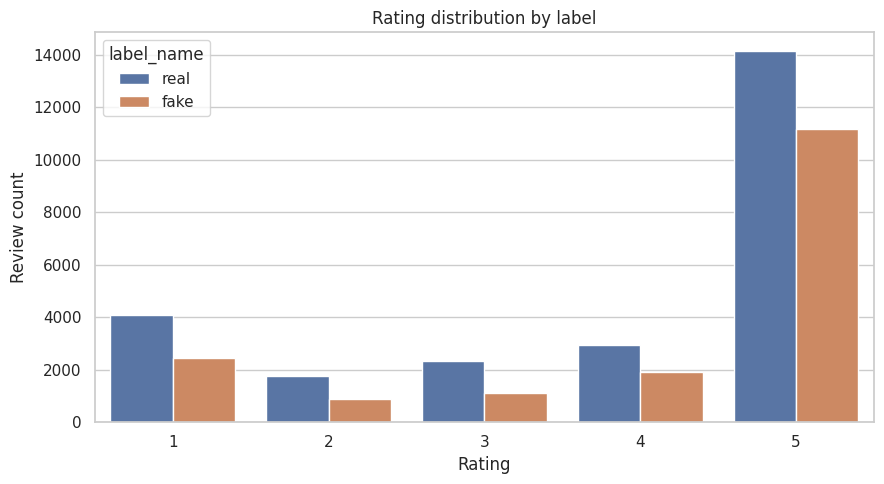

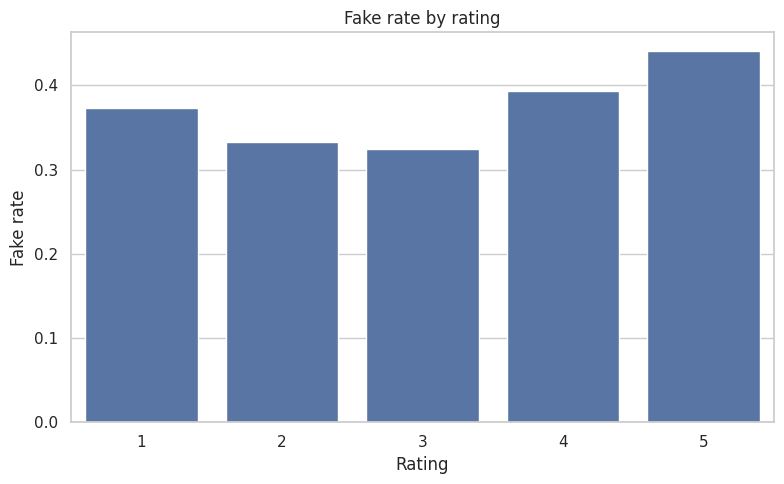

In [21]:
# rating_available: kiểm tra dataset có cột rating để phân tích EDA-07
rating_available = RATING_ANALYSIS_COL is not None and RATING_ANALYSIS_COL in clean_df.columns
# if rating_available: thống kê phân phối rating và fake rate theo rating
if rating_available:
    # rating_df = ...: gán giá trị cho biến rating df
    rating_df = clean_df.copy()
    # _rating_numeric: chuyển rating sang số, lỗi thành NaN
    rating_df['_rating_numeric'] = pd.to_numeric(rating_df[RATING_ANALYSIS_COL], errors='coerce')
    # rating_df = ...: xóa dòng/cột có giá trị thiếu
    rating_df = rating_df.dropna(subset=['_rating_numeric']).copy()

    # rating_dist: số review và số fake theo từng cặp (nhãn, rating)
    rating_dist = rating_df.groupby(['label_name', '_rating_numeric']).agg(review_count=(TEXT_COL, 'size'), fake_count=('_is_fake', 'sum')).reset_index()
    # rating_dist['fake_rate'] = rating_dist['fake_count'] / rating_dist['review_count...: thực thi lệnh Python
    rating_dist['fake_rate'] = rating_dist['fake_count'] / rating_dist['review_count']
    # rating_dist['stat_type'] = 'rating_distribution_by_label': ép kiểu chuỗi
    rating_dist['stat_type'] = 'rating_distribution_by_label'
    # fake_rate_by_rating = ...: nhóm dữ liệu theo cột
    fake_rate_by_rating = rating_df.groupby('_rating_numeric').agg(review_count=(TEXT_COL, 'size'), fake_count=('_is_fake', 'sum')).reset_index()
    # fake_rate_by_rating['fake_rate'] = fake_rate_by_rating['fake_count'] / fake_rate...: thực thi lệnh Python
    fake_rate_by_rating['fake_rate'] = fake_rate_by_rating['fake_count'] / fake_rate_by_rating['review_count']
    # fake_rate_by_rating['label_name'] = 'all': thực thi lệnh Python
    fake_rate_by_rating['label_name'] = 'all'
    # fake_rate_by_rating['stat_type'] = 'fake_rate_by_rating': thực thi lệnh Python
    fake_rate_by_rating['stat_type'] = 'fake_rate_by_rating'
    # rating_summary = ...: thống kê mô tả
    rating_summary = rating_df.groupby('label_name')['_rating_numeric'].describe().reset_index()
    # rating_summary['stat_type'] = 'rating_summary_by_label': tính tổng
    rating_summary['stat_type'] = 'rating_summary_by_label'
    # min_rating = ...: lấy giá trị nhỏ nhất
    min_rating = rating_df['_rating_numeric'].min()
    # max_rating = ...: lấy giá trị lớn nhất
    max_rating = rating_df['_rating_numeric'].max()
    # extreme_rating_stats = ...: nhóm dữ liệu theo cột
    extreme_rating_stats = rating_df[rating_df['_rating_numeric'].isin([min_rating, max_rating])].groupby(['label_name', '_rating_numeric']).agg(review_count=(TEXT_COL, 'size'), fake_count=('_is_fake', 'sum')).reset_index()
    # extreme_rating_stats['fake_rate'] = extreme_rating_stats['fake_count'] / extreme...: thực thi lệnh Python
    extreme_rating_stats['fake_rate'] = extreme_rating_stats['fake_count'] / extreme_rating_stats['review_count']
    # extreme_rating_stats['stat_type'] = 'extreme_rating_stats': thực thi lệnh Python
    extreme_rating_stats['stat_type'] = 'extreme_rating_stats'
    # rating_label_stats = ...: nối nhiều DataFrame
    rating_label_stats = pd.concat([rating_dist, fake_rate_by_rating, extreme_rating_stats, rating_summary], ignore_index=True, sort=False)
    # rating_status = ...: gán giá trị cho biến rating status
    rating_status = 'generated'
    # rating_note = ...: gán giá trị cho biến rating note
    rating_note = ''
# else: nhánh còn lại của điều kiện
else:
    # rating_label_stats = ...: gán giá trị cho biến rating label stats
    rating_label_stats = pd.DataFrame([{'stat_type': 'skipped', 'rating_column': RATING_ANALYSIS_COL, 'note': 'Rating column missing.'}])
    # rating_status = ...: gán giá trị cho biến rating status
    rating_status = 'skipped'
    # rating_note = ...: gán giá trị cho biến rating note
    rating_note = 'Rating column missing.'

# rating_stats_path: đường dẫn lưu bảng thống kê rating theo nhãn
rating_stats_path = REPORT_TABLE_DIR / 'phase1_rating_label_stats.csv'
# rating_label_stats.to_csv(rating_stats_path, index=False): ghi DataFrame ra file CSV
rating_label_stats.to_csv(rating_stats_path, index=False)
# record_advanced_artifact('EDA-07', 'table', rating_stats_path, status=rating_sta...: thực thi lệnh Python
record_advanced_artifact('EDA-07', 'table', rating_stats_path, status=rating_status, note=rating_note)
# display(rating_label_stats.head(20)): hiển thị bảng/kết quả trên notebook
display(rating_label_stats.head(20))

# if rating_status == 'generated': vẽ biểu đồ rating nếu phân tích thành công
if rating_status == 'generated':
    # fig, ax = plt.subplots(figsize=(9, 5)): thực thi lệnh Python
    fig, ax = plt.subplots(figsize=(9, 5))
    # sns.countplot: phân phối rating theo nhãn
    sns.countplot(data=rating_df, x='_rating_numeric', hue='label_name', ax=ax)
    # ax.set_title('Rating distribution by label'): tạo tập hợp
    ax.set_title('Rating distribution by label')
    # ax.set_xlabel('Rating'): tạo tập hợp
    ax.set_xlabel('Rating')
    # ax.set_ylabel('Review count'): tạo tập hợp
    ax.set_ylabel('Review count')
    # plt.tight_layout(): tự chỉnh lề biểu đồ
    plt.tight_layout()
    # rating_vs_label_path = ...: gán giá trị cho biến rating vs label path
    rating_vs_label_path = REPORT_FIGURE_DIR / 'phase1_rating_vs_label.png'
    # plt.savefig(rating_vs_label_path, dpi=160, bbox_inches='tight'): lưu biểu đồ ra file hình
    plt.savefig(rating_vs_label_path, dpi=160, bbox_inches='tight')
    # plt.show(): hiển thị biểu đồ
    plt.show()
    # record_advanced_artifact('EDA-07', 'figure', rating_vs_label_path): thực thi lệnh Python
    record_advanced_artifact('EDA-07', 'figure', rating_vs_label_path)

    # fig, ax = plt.subplots(figsize=(8, 5)): thực thi lệnh Python
    fig, ax = plt.subplots(figsize=(8, 5))
    # sns.barplot(data=fake_rate_by_rating, x='_rating_numeric', y='fake_rate', ax=ax): vẽ barplot seaborn
    sns.barplot(data=fake_rate_by_rating, x='_rating_numeric', y='fake_rate', ax=ax)
    # ax.set_title('Fake rate by rating'): tạo tập hợp
    ax.set_title('Fake rate by rating')
    # ax.set_xlabel('Rating'): tạo tập hợp
    ax.set_xlabel('Rating')
    # ax.set_ylabel('Fake rate'): tạo tập hợp
    ax.set_ylabel('Fake rate')
    # plt.tight_layout(): tự chỉnh lề biểu đồ
    plt.tight_layout()
    # fake_rate_rating_path = ...: gán giá trị cho biến fake rate rating path
    fake_rate_rating_path = REPORT_FIGURE_DIR / 'phase1_fake_rate_by_rating.png'
    # plt.savefig(fake_rate_rating_path, dpi=160, bbox_inches='tight'): lưu biểu đồ ra file hình
    plt.savefig(fake_rate_rating_path, dpi=160, bbox_inches='tight')
    # plt.show(): hiển thị biểu đồ
    plt.show()
    # record_advanced_artifact('EDA-07', 'figure', fake_rate_rating_path): thực thi lệnh Python
    record_advanced_artifact('EDA-07', 'figure', fake_rate_rating_path)
# else: nhánh còn lại của điều kiện
else:
    # for: vòng lặp — for fig_name in ['phase1_rating_vs_label.png', 'phase1_fake_rate_by_ra
    for fig_name in ['phase1_rating_vs_label.png', 'phase1_fake_rate_by_rating.png']:
        # record_advanced_artifact('EDA-07', 'figure', REPORT_FIGURE_DIR / fig_name, statu...: thực thi lệnh Python
        record_advanced_artifact('EDA-07', 'figure', REPORT_FIGURE_DIR / fig_name, status='skipped', note=rating_note)


,asin,review_count,fake_count,real_count,fake_rate
1963,B00EEN2HCS,121,44,77,0.363636
1239,B007IAE5WY,96,34,62,0.354167
10939,B07C533XCW,93,29,64,0.311828
3383,B00R1TAN7I,91,38,53,0.417582
19530,B08L5KN7X4,80,32,48,0.400000
5133,B019GBG0IE,79,17,62,0.215190
8552,B0719KWG8H,69,28,41,0.405797
1461,B0092MCQZ4,68,26,42,0.382353
4211,B0107QYW14,57,29,28,0.508772
14540,B07TK2PSJF,51,21,30,0.411765


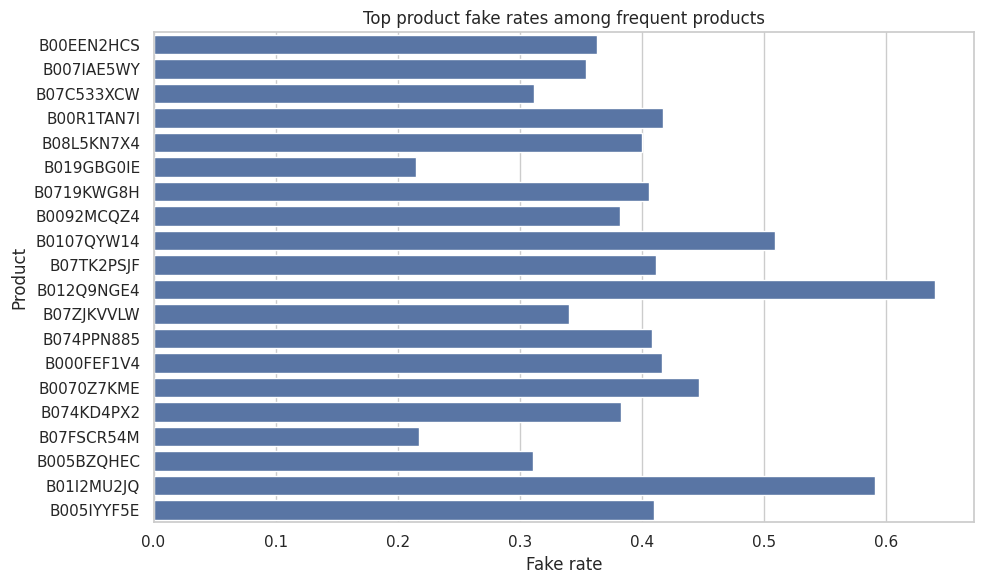

,category_column,status,note
0,None,skipped,No category-like column found.


,requirement,artifact_type,path,status,note,generated_at_utc,label_name_map,clean_rows
0,EDA-01,table,/content/drive/MyDrive/Fake_reviews/reports/tables/phase1_length_by_label.csv,generated,,2026-05-31T12:51:11.410766+00:00,"{""0"": ""real"", ""1"": ""fake""}",42749
1,EDA-01,figure,/content/drive/MyDrive/Fake_reviews/reports/figures/phase1_length_by_label_boxplot.png,generated,,2026-05-31T12:51:11.410766+00:00,"{""0"": ""real"", ""1"": ""fake""}",42749
2,EDA-01,figure,/content/drive/MyDrive/Fake_reviews/reports/figures/phase1_word_count_by_label_boxplot.png,generated,,2026-05-31T12:51:11.410766+00:00,"{""0"": ""real"", ""1"": ""fake""}",42749
3,EDA-02,table,/content/drive/MyDrive/Fake_reviews/reports/tables/phase1_samples_by_label.csv,generated,Contains raw review text.,2026-05-31T12:51:11.410766+00:00,"{""0"": ""real"", ""1"": ""fake""}",42749
4,EDA-03,table,/content/drive/MyDrive/Fake_reviews/reports/tables/phase1_sentiment_by_label.csv,generated,,2026-05-31T12:51:11.410766+00:00,"{""0"": ""real"", ""1"": ""fake""}",42749
5,EDA-03,figure,/content/drive/MyDrive/Fake_reviews/reports/figures/phase1_sentiment_by_label.png,generated,,2026-05-31T12:51:11.410766+00:00,"{""0"": ""real"", ""1"": ""fake""}",42749
6,EDA-04,table,/content/drive/MyDrive/Fake_reviews/reports/tables/phase1_top_terms_by_label.csv,generated,,2026-05-31T12:51:11.410766+00:00,"{""0"": ""real"", ""1"": ""fake""}",42749
7,EDA-04,figure,/content/drive/MyDrive/Fake_reviews/reports/figures/phase1_top_terms_by_label.png,generated,,2026-05-31T12:51:11.410766+00:00,"{""0"": ""real"", ""1"": ""fake""}",42749
8,EDA-04,optional_figure,/content/drive/MyDrive/Fake_reviews/reports/figures/phase1_wordcloud_<label_name>.png,skipped,ENABLE_WORDCLOUD is False by default.,2026-05-31T12:51:11.410766+00:00,"{""0"": ""real"", ""1"": ""fake""}",42749
9,EDA-05,table,/content/drive/MyDrive/Fake_reviews/reports/tables/phase1_temporal_stats.csv,generated,,2026-05-31T12:51:11.410766+00:00,"{""0"": ""real"", ""1"": ""fake""}",42749


Saved advanced EDA summary: /content/drive/MyDrive/Fake_reviews/reports/tables/phase1_advanced_eda_summary.csv


In [22]:
# product_available: kiểm tra có cột product để phân tích EDA-08
product_available = PRODUCT_ANALYSIS_COL is not None and PRODUCT_ANALYSIS_COL in clean_df.columns
# if product_available: tính fake rate theo từng sản phẩm
if product_available:
    # product_fake_rate = ...: nhóm dữ liệu theo cột
    product_fake_rate = clean_df.groupby(PRODUCT_ANALYSIS_COL).agg(review_count=(TEXT_COL, 'size'), fake_count=('_is_fake', 'sum')).reset_index()
    # product_fake_rate['real_count'] = product_fake_rate['review_count'] - product_fa...: thực thi lệnh Python
    product_fake_rate['real_count'] = product_fake_rate['review_count'] - product_fake_rate['fake_count']
    # product_fake_rate['fake_rate'] = product_fake_rate['fake_count'] / product_fake_...: thực thi lệnh Python
    product_fake_rate['fake_rate'] = product_fake_rate['fake_count'] / product_fake_rate['review_count']
    # product_fake_rate = ...: gán giá trị cho biến product fake rate
    product_fake_rate = product_fake_rate.sort_values(['review_count', 'fake_rate'], ascending=False)
    # product_status = ...: gán giá trị cho biến product status
    product_status = 'generated'
    # product_note = ...: gán giá trị cho biến product note
    product_note = ''
# else: nhánh còn lại của điều kiện
else:
    # product_fake_rate = ...: gán giá trị cho biến product fake rate
    product_fake_rate = pd.DataFrame([{'product_column': PRODUCT_ANALYSIS_COL, 'status': 'skipped', 'note': 'Product column missing.'}])
    # product_status = ...: gán giá trị cho biến product status
    product_status = 'skipped'
    # product_note = ...: gán giá trị cho biến product note
    product_note = 'Product column missing.'

# product_fake_rate_path = ...: gán giá trị cho biến product fake rate path
product_fake_rate_path = REPORT_TABLE_DIR / 'phase1_product_fake_rate.csv'
# product_fake_rate.to_csv(product_fake_rate_path, index=False): ghi DataFrame ra file CSV
product_fake_rate.to_csv(product_fake_rate_path, index=False)
# record_advanced_artifact('EDA-08', 'table', product_fake_rate_path, status=produ...: thực thi lệnh Python
record_advanced_artifact('EDA-08', 'table', product_fake_rate_path, status=product_status, note=product_note)
# display(product_fake_rate.head(20)): hiển thị bảng/kết quả trên notebook
display(product_fake_rate.head(20))

# if: kiểm tra điều kiện — if product_status == 'generated':
if product_status == 'generated':
    # top_products = ...: xem vài dòng đầu
    top_products = product_fake_rate[product_fake_rate['review_count'] >= 3].head(20)
    # if: kiểm tra điều kiện — if len(top_products) == 0:
    if len(top_products) == 0:
        # top_products = ...: xem vài dòng đầu
        top_products = product_fake_rate.head(20)
    # fig, ax = plt.subplots(figsize=(10, 6)): thực thi lệnh Python
    fig, ax = plt.subplots(figsize=(10, 6))
    # sns.barplot(data=top_products, x='fake_rate', y=PRODUCT_ANALYSIS_COL, ax=ax): vẽ barplot seaborn
    sns.barplot(data=top_products, x='fake_rate', y=PRODUCT_ANALYSIS_COL, ax=ax)
    # ax.set_title('Top product fake rates among frequent products'): tạo tập hợp
    ax.set_title('Top product fake rates among frequent products')
    # ax.set_xlabel('Fake rate'): tạo tập hợp
    ax.set_xlabel('Fake rate')
    # ax.set_ylabel('Product'): tạo tập hợp
    ax.set_ylabel('Product')
    # plt.tight_layout(): tự chỉnh lề biểu đồ
    plt.tight_layout()
    # top_product_fake_rate_path = ...: gán giá trị cho biến top product fake rate path
    top_product_fake_rate_path = REPORT_FIGURE_DIR / 'phase1_top_product_fake_rate.png'
    # plt.savefig(top_product_fake_rate_path, dpi=160, bbox_inches='tight'): lưu biểu đồ ra file hình
    plt.savefig(top_product_fake_rate_path, dpi=160, bbox_inches='tight')
    # plt.show(): hiển thị biểu đồ
    plt.show()
    # record_advanced_artifact('EDA-08', 'figure', top_product_fake_rate_path): thực thi lệnh Python
    record_advanced_artifact('EDA-08', 'figure', top_product_fake_rate_path)
# else: nhánh còn lại của điều kiện
else:
    # record_advanced_artifact('EDA-08', 'figure', REPORT_FIGURE_DIR / 'phase1_top_pro...: thực thi lệnh Python
    record_advanced_artifact('EDA-08', 'figure', REPORT_FIGURE_DIR / 'phase1_top_product_fake_rate.png', status='skipped', note=product_note)

# category_candidates: danh sách tên cột ứng viên cho category
category_candidates = ['category', 'main_category', 'product_category', 'categories', 'department', 'store', 'brand_category', 'category_name']
# category_analysis_col: tìm cột category đầu tiên có trong dataset
category_analysis_col = next((col for col in category_candidates if col in clean_df.columns and col not in {TEXT_COL, LABEL_BINARY_COL, PRODUCT_ANALYSIS_COL}), None)
# if category_analysis_col: phân tích fake rate theo category
if category_analysis_col is not None:
    # category_fake_rate = ...: nhóm dữ liệu theo cột
    category_fake_rate = clean_df.groupby(category_analysis_col).agg(review_count=(TEXT_COL, 'size'), fake_count=('_is_fake', 'sum')).reset_index()
    # category_fake_rate['real_count'] = category_fake_rate['review_count'] - category...: thực thi lệnh Python
    category_fake_rate['real_count'] = category_fake_rate['review_count'] - category_fake_rate['fake_count']
    # category_fake_rate['fake_rate'] = category_fake_rate['fake_count'] / category_fa...: thực thi lệnh Python
    category_fake_rate['fake_rate'] = category_fake_rate['fake_count'] / category_fake_rate['review_count']
    # category_fake_rate = ...: gán giá trị cho biến category fake rate
    category_fake_rate = category_fake_rate.sort_values(['review_count', 'fake_rate'], ascending=False)
    # category_status = ...: gán giá trị cho biến category status
    category_status = 'generated'
    # category_note = ...: gán giá trị cho biến category note
    category_note = ''
# else: nhánh còn lại của điều kiện
else:
    # category_fake_rate = ...: gán giá trị cho biến category fake rate
    category_fake_rate = pd.DataFrame([{'category_column': category_analysis_col, 'status': 'skipped', 'note': 'No category-like column found.'}])
    # category_status = ...: gán giá trị cho biến category status
    category_status = 'skipped'
    # category_note = ...: gán giá trị cho biến category note
    category_note = 'No category-like column found.'

# category_fake_rate_path = ...: gán giá trị cho biến category fake rate path
category_fake_rate_path = REPORT_TABLE_DIR / 'phase1_category_fake_rate.csv'
# category_fake_rate.to_csv(category_fake_rate_path, index=False): ghi DataFrame ra file CSV
category_fake_rate.to_csv(category_fake_rate_path, index=False)
# record_advanced_artifact('EDA-08', 'table', category_fake_rate_path, status=cate...: thực thi lệnh Python
record_advanced_artifact('EDA-08', 'table', category_fake_rate_path, status=category_status, note=category_note)
# display(category_fake_rate.head(20)): hiển thị bảng/kết quả trên notebook
display(category_fake_rate.head(20))

# if: kiểm tra điều kiện — if category_status == 'generated':
if category_status == 'generated':
    # fig, ax = plt.subplots(figsize=(10, 6)): thực thi lệnh Python
    fig, ax = plt.subplots(figsize=(10, 6))
    # sns.barplot(data=category_fake_rate.head(20), x='fake_rate', y=category_analysis...: vẽ barplot seaborn
    sns.barplot(data=category_fake_rate.head(20), x='fake_rate', y=category_analysis_col, ax=ax)
    # ax.set_title('Category fake rate'): tạo tập hợp
    ax.set_title('Category fake rate')
    # ax.set_xlabel('Fake rate'): tạo tập hợp
    ax.set_xlabel('Fake rate')
    # ax.set_ylabel('Category'): tạo tập hợp
    ax.set_ylabel('Category')
    # plt.tight_layout(): tự chỉnh lề biểu đồ
    plt.tight_layout()
    # category_fake_rate_figure_path = ...: gán giá trị cho biến category fake rate figure path
    category_fake_rate_figure_path = REPORT_FIGURE_DIR / 'phase1_category_fake_rate.png'
    # plt.savefig(category_fake_rate_figure_path, dpi=160, bbox_inches='tight'): lưu biểu đồ ra file hình
    plt.savefig(category_fake_rate_figure_path, dpi=160, bbox_inches='tight')
    # plt.show(): hiển thị biểu đồ
    plt.show()
    # record_advanced_artifact('EDA-08', 'figure', category_fake_rate_figure_path): thực thi lệnh Python
    record_advanced_artifact('EDA-08', 'figure', category_fake_rate_figure_path)
# else: nhánh còn lại của điều kiện
else:
    # record_advanced_artifact('EDA-08', 'figure', REPORT_FIGURE_DIR / 'phase1_categor...: thực thi lệnh Python
    record_advanced_artifact('EDA-08', 'figure', REPORT_FIGURE_DIR / 'phase1_category_fake_rate.png', status='skipped', note=category_note)

# expected_advanced_artifacts: danh sách artifact EDA nâng cao kỳ vọng phải có
expected_advanced_artifacts = [
    # ('EDA-01', 'reports/tables/phase1_length_by_label.csv'),: đếm số phần tử
    ('EDA-01', 'reports/tables/phase1_length_by_label.csv'),
    # ('EDA-01', 'reports/figures/phase1_length_by_label_boxplot.png'),: đếm số phần tử
    ('EDA-01', 'reports/figures/phase1_length_by_label_boxplot.png'),
    # ('EDA-01', 'reports/figures/phase1_word_count_by_label_boxplot.png'),: thực thi lệnh Python
    ('EDA-01', 'reports/figures/phase1_word_count_by_label_boxplot.png'),
    # ('EDA-02', 'reports/tables/phase1_samples_by_label.csv'),: thực thi lệnh Python
    ('EDA-02', 'reports/tables/phase1_samples_by_label.csv'),
    # ('EDA-03', 'reports/tables/phase1_sentiment_by_label.csv'),: thực thi lệnh Python
    ('EDA-03', 'reports/tables/phase1_sentiment_by_label.csv'),
    # ('EDA-03', 'reports/figures/phase1_sentiment_by_label.png'),: thực thi lệnh Python
    ('EDA-03', 'reports/figures/phase1_sentiment_by_label.png'),
    # ('EDA-04', 'reports/tables/phase1_top_terms_by_label.csv'),: thực thi lệnh Python
    ('EDA-04', 'reports/tables/phase1_top_terms_by_label.csv'),
    # ('EDA-04', 'reports/figures/phase1_top_terms_by_label.png'),: thực thi lệnh Python
    ('EDA-04', 'reports/figures/phase1_top_terms_by_label.png'),
    # ('EDA-04', 'reports/figures/phase1_wordcloud_<label_name>.png'),: thực thi lệnh Python
    ('EDA-04', 'reports/figures/phase1_wordcloud_<label_name>.png'),
    # ('EDA-05', 'reports/tables/phase1_temporal_stats.csv'),: thực thi lệnh Python
    ('EDA-05', 'reports/tables/phase1_temporal_stats.csv'),
    # ('EDA-05', 'reports/figures/phase1_review_volume_over_time.png'),: thực thi lệnh Python
    ('EDA-05', 'reports/figures/phase1_review_volume_over_time.png'),
    # ('EDA-05', 'reports/figures/phase1_fake_rate_by_time.png'),: thực thi lệnh Python
    ('EDA-05', 'reports/figures/phase1_fake_rate_by_time.png'),
    # ('EDA-05', 'reports/figures/phase1_fake_rate_by_hour.png'),: thực thi lệnh Python
    ('EDA-05', 'reports/figures/phase1_fake_rate_by_hour.png'),
    # ('EDA-06', 'reports/tables/phase1_user_burst_stats.csv'),: thực thi lệnh Python
    ('EDA-06', 'reports/tables/phase1_user_burst_stats.csv'),
    # ('EDA-07', 'reports/tables/phase1_rating_label_stats.csv'),: thực thi lệnh Python
    ('EDA-07', 'reports/tables/phase1_rating_label_stats.csv'),
    # ('EDA-07', 'reports/figures/phase1_rating_vs_label.png'),: thực thi lệnh Python
    ('EDA-07', 'reports/figures/phase1_rating_vs_label.png'),
    # ('EDA-07', 'reports/figures/phase1_fake_rate_by_rating.png'),: thực thi lệnh Python
    ('EDA-07', 'reports/figures/phase1_fake_rate_by_rating.png'),
    # ('EDA-08', 'reports/tables/phase1_product_fake_rate.csv'),: thực thi lệnh Python
    ('EDA-08', 'reports/tables/phase1_product_fake_rate.csv'),
    # ('EDA-08', 'reports/figures/phase1_top_product_fake_rate.png'),: thực thi lệnh Python
    ('EDA-08', 'reports/figures/phase1_top_product_fake_rate.png'),
    # ('EDA-08', 'reports/tables/phase1_category_fake_rate.csv'),: thực thi lệnh Python
    ('EDA-08', 'reports/tables/phase1_category_fake_rate.csv'),
    # ('EDA-08', 'reports/figures/phase1_category_fake_rate.png'),: thực thi lệnh Python
    ('EDA-08', 'reports/figures/phase1_category_fake_rate.png'),
# ]: đóng khối danh sách
]

# summary_df = ...: tính tổng
summary_df = pd.DataFrame(advanced_artifacts)
# if: kiểm tra điều kiện — if len(summary_df) == 0:
if len(summary_df) == 0:
    # summary_df = ...: tính tổng
    summary_df = pd.DataFrame(columns=['requirement', 'artifact_type', 'path', 'status', 'note'])
# recorded_paths = ...: ép kiểu dữ liệu cột
recorded_paths = set(summary_df['path'].astype(str)) if 'path' in summary_df.columns else set()
# missing_rows = ...: gán giá trị cho biến missing rows
missing_rows = []
# for: vòng lặp — for requirement, relative_path in expected_advanced_artifacts:
for requirement, relative_path in expected_advanced_artifacts:
    # absolute_path = ...: ép kiểu chuỗi
    absolute_path = str(PROJECT_ROOT / relative_path)
    # placeholder_path = ...: ép kiểu chuỗi
    placeholder_path = str(REPORT_FIGURE_DIR / 'phase1_wordcloud_<label_name>.png')
    # if: kiểm tra điều kiện — if absolute_path not in recorded_paths and placeholder_path not in rec
    if absolute_path not in recorded_paths and placeholder_path not in recorded_paths:
        # missing_rows.append({: thực thi lệnh Python
        missing_rows.append({
            # 'requirement': requirement,: thực thi lệnh Python
            'requirement': requirement,
            # 'artifact_type': 'expected_artifact',: thực thi lệnh Python
            'artifact_type': 'expected_artifact',
            # 'path': absolute_path,: thực thi lệnh Python
            'path': absolute_path,
            # 'status': 'not_recorded',: thực thi lệnh Python
            'status': 'not_recorded',
            # 'note': 'Expected artifact was not recorded by earlier cells.',: thực thi lệnh Python
            'note': 'Expected artifact was not recorded by earlier cells.',
        # }): đóng từ điển hoặc DataFrame constructor
        })
# if: kiểm tra điều kiện — if missing_rows:
if missing_rows:
    # summary_df = ...: nối nhiều DataFrame
    summary_df = pd.concat([summary_df, pd.DataFrame(missing_rows)], ignore_index=True)
# summary_df['generated_at_utc'] = datetime.now(timezone.utc).isoformat(): tính tổng
summary_df['generated_at_utc'] = datetime.now(timezone.utc).isoformat()
# summary_df['label_name_map'] = json.dumps(LABEL_NAME_MAP, ensure_ascii=False): ghi dictionary ra JSON
summary_df['label_name_map'] = json.dumps(LABEL_NAME_MAP, ensure_ascii=False)
# summary_df['clean_rows'] = int(len(clean_df)): đếm số phần tử
summary_df['clean_rows'] = int(len(clean_df))

# advanced_summary_path: đường dẫn bảng tổng hợp tất cả artifact EDA nâng cao
advanced_summary_path = REPORT_TABLE_DIR / 'phase1_advanced_eda_summary.csv'
# summary_df.to_csv(advanced_summary_path, index=False): ghi DataFrame ra file CSV
summary_df.to_csv(advanced_summary_path, index=False)
# display(summary_df): hiển thị bảng/kết quả trên notebook
display(summary_df)
# print('Saved advanced EDA summary:', advanced_summary_path): in thông tin ra console
print('Saved advanced EDA summary:', advanced_summary_path)


## Phase 1.1 Completion Checklist

- **EDA-01:** Review length distribution by label for character length and word count.
- **EDA-02:** Sample reviews by fake/real class for qualitative inspection.
- **EDA-03:** Sentiment distribution by label using VADER or TextBlob fallback.
- **EDA-04:** Word frequency, unigram/bigram/trigram tables, and optional word cloud by class.
- **EDA-05:** Temporal review volume and fake-rate analysis by date/week/day/hour when timestamp is available.
- **EDA-06:** User burst analysis when reviewer and timestamp columns are available.
- **EDA-07:** Rating-vs-label and extreme-rating analysis when rating is available.
- **EDA-08:** Product-level fake-rate stats and category-level stats when category exists.

Expected Phase 1.1 output files:

- `reports/tables/phase1_length_by_label.csv`
- `reports/tables/phase1_samples_by_label.csv`
- `reports/tables/phase1_sentiment_by_label.csv`
- `reports/tables/phase1_top_terms_by_label.csv`
- `reports/tables/phase1_temporal_stats.csv`
- `reports/tables/phase1_user_burst_stats.csv`
- `reports/tables/phase1_rating_label_stats.csv`
- `reports/tables/phase1_product_fake_rate.csv`
- `reports/tables/phase1_category_fake_rate.csv`
- `reports/tables/phase1_advanced_eda_summary.csv`
- `reports/figures/phase1_length_by_label_boxplot.png`
- `reports/figures/phase1_word_count_by_label_boxplot.png`
- `reports/figures/phase1_sentiment_by_label.png`
- `reports/figures/phase1_top_terms_by_label.png`
- `reports/figures/phase1_review_volume_over_time.png`
- `reports/figures/phase1_fake_rate_by_time.png`
- `reports/figures/phase1_fake_rate_by_hour.png`
- `reports/figures/phase1_rating_vs_label.png`
- `reports/figures/phase1_fake_rate_by_rating.png`
- `reports/figures/phase1_top_product_fake_rate.png`
- `reports/figures/phase1_category_fake_rate.png`
